In [3]:
import tensorflow as tf
import sys

print(f"TensorFlow version: {tf.__version__}")
print(f"Python version: {sys.version}")

# Простая проверка
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=(5,), activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')


2025-11-24 23:20:49.216892: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-24 23:20:49.220315: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-24 23:20:49.325578: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-24 23:20:49.328953: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-24 23:20:50.829591: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

TensorFlow version: 2.13.0
Python version: 3.11.9 (main, Jul  4 2025, 16:52:54) [GCC 14.2.0]


2025-11-24 23:20:54.201033: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-24 23:20:54.353934: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
# отключим предупреждения
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Отключает большинство предупреждений TensorFlow
import tensorflow as tf

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, mean_squared_error, r2_score, accuracy_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import shap
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import re

# Загрузка
df = pd.read_csv('NYSE.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company                152 non-null    object 
 1   Name                   152 non-null    object 
 2   Exchange               152 non-null    object 
 3   Sector                 152 non-null    object 
 4   Industry               152 non-null    object 
 5   Market Cap             152 non-null    object 
 6   P/E Ratio              151 non-null    object 
 7   PEG Ratio              143 non-null    float64
 8   Last Trade Price       152 non-null    object 
 9   Day Change (%)         152 non-null    object 
 10  Analyst Target Upside  148 non-null    object 
 11  Name.1                 152 non-null    object 
 12  Symbol                 152 non-null    object 
 13  Beta (5y)              152 non-null    object 
 14  Beta (1y)              152 non-null    object 
 15  Quick 

Первая часть работы будет посвящена бинарной классификации. Выполним подготовку данных для бинарной классификации на основе поля "Analyst Target Upside", которое отражает аналитические прогнозы по потенциальному росту (Upside) или падению (Downside) цены акции относительно текущего уровня

In [4]:
# парсинг Analyst Target Upside
def parse_upside(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    match = re.search(r'([+-]?\d*\.?\d+)', s)
    if not match:
        return np.nan
    num = float(match.group(1))
    if 'Downside' in s:
        return -abs(num)
    elif 'Upside' in s:
        return abs(num)
    else:
        return num

df['upside_numeric'] = df['Analyst Target Upside'].apply(parse_upside)
df['target'] = (df['upside_numeric'] > 0).astype(int)

# Удаляем строки, где нет числового таргета
df = df.dropna(subset=['upside_numeric']).reset_index(drop=True)

# Проверка распределения классов
print("Распределение целевой переменной:")
print(df['target'].value_counts())
print("Доля класса 1 (Upside):", df['target'].mean())

# Очистка признаков
feature_cols = [
    'P/E Ratio', 'PEG Ratio', 'Beta (5y)', 'Beta (1y)',
    'Quick Ratio', 'Current Ratio',
    'Debt to Equity', 'Debt to Assets', 'Net Debt to Capital'
]

def clean_numeric(val):
    if pd.isna(val) or val == 'blank':
        return np.nan
    s = str(val).strip()
    # Удаляем нечисловые суффиксы, но сохраняем знак и точку
    s = re.sub(r'[^\d\.\+\-]', '', s)
    try:
        # Убираем двойные знаки вроде "--" или "++"
        if s.count('+') + s.count('-') > 1:
            return np.nan
        return float(s)
    except:
        return np.nan

for col in feature_cols:
    df[col] = df[col].apply(clean_numeric)

# Финальный отбор без пропусков
final_df = df.dropna(subset=feature_cols + ['target']).reset_index(drop=True)
X = final_df[feature_cols]
y = final_df['target'].astype(int)

print("\nФорма после очистки:", X.shape)
print("Распределение классов в итоговом датасете:")
print(y.value_counts())
print("Доля Upside:", y.mean())


Распределение целевой переменной:
target
1    120
0     28
Name: count, dtype: int64
Доля класса 1 (Upside): 0.8108108108108109

Форма после очистки: (137, 9)
Распределение классов в итоговом датасете:
target
1    112
0     25
Name: count, dtype: int64
Доля Upside: 0.8175182481751825


В датасете наблюдается выраженный дисбаланс классов: 82% компаний имеют положительный прогноз аналитиков (Upside > 0%). Это требует использования метрик, устойчивых к дисбалансу (ROC-AUC, F1-score), и осторожной интерпретации точности. При анализе SHAP-значений особое внимание уделено примерам из миноритарного класса (Downside), чтобы выявить ключевые факторы, снижающие ожидаемую доходность. 

In [5]:
# Разделение на тренировочные и тестовые выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Масштабирование (для лог. регрессии) 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score

# 1. Логистическая регрессия (с class_weight='balanced')
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 2. Random Forest (с class_weight='balanced')
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',
    random_state=42)
rf.fit(X_train, y_train)

# 3. Gradient Boosting (встроенный параметр class_weight нет, но можно sample_weight)
sample_weight = compute_sample_weight('balanced', y_train)

gb = GradientBoostingClassifier(
n_estimators=95,
max_depth=5,
random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weight)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,95
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [41]:
# оценка моделей

# from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest': (rf, X_test),
    'Gradient Boosting': (gb, X_test)}

results = {}
for name, (model, X_t) in models.items():
    y_pred = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro')}

results_df = pd.DataFrame(results).T
print(results_df.round(3))

                     Accuracy  ROC-AUC  F1 (macro)
Logistic Regression     0.750    0.835       0.681
Random Forest           0.893    0.748       0.755
Gradient Boosting       0.821    0.817       0.717


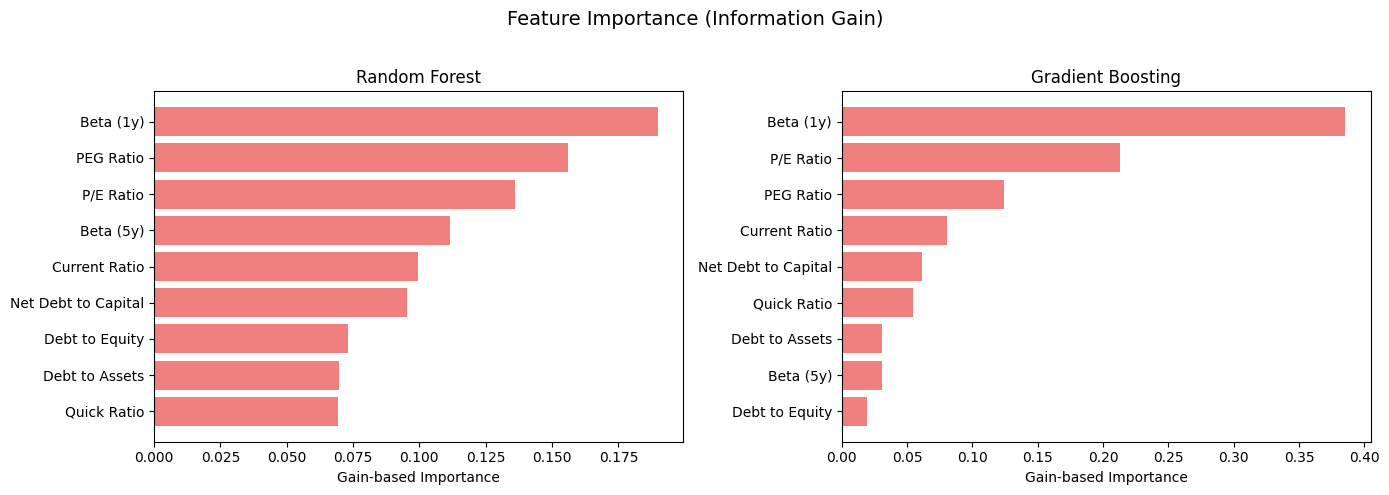

In [42]:
# Feature Importance (IG)
ig_models = [("Random Forest", rf), ("Gradient Boosting", gb)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, model) in zip(axes, ig_models):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    ax.barh(range(len(feature_cols)), importances[indices], color='lightcoral')
    ax.set_yticks(range(len(feature_cols)))
    ax.set_yticklabels([feature_cols[i] for i in indices])
    ax.set_xlabel('Gain-based Importance')
    ax.set_title(f'{name}')
    ax.invert_yaxis()
plt.suptitle('Feature Importance (Information Gain)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


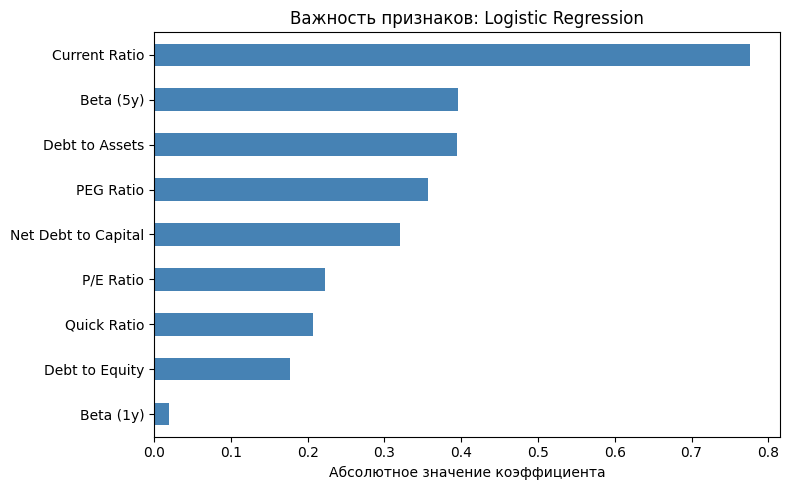

In [43]:
# Важность для логистической регрессии (коэффициенты)
lr_coefs = pd.Series(lr.coef_[0], index=feature_cols)
lr_importance = lr_coefs.abs().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
lr_importance.plot(kind='barh', color='steelblue')
plt.xlabel('Абсолютное значение коэффициента')
plt.title('Важность признаков: Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

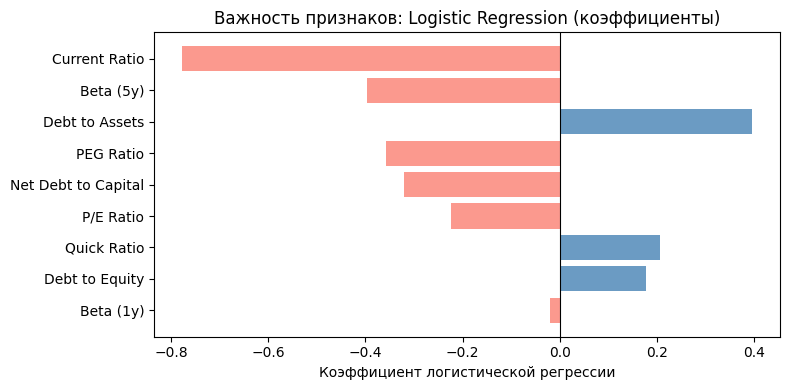

In [44]:
#  Извлекаем коэффициенты
coef = lr.coef_[0]  # shape: (n_features,)
features = np.array(feature_cols)

#  Сортируем по абсолютному значению
sorted_idx = np.argsort(np.abs(coef))[::-1]  # от самого важного к наименее

plt.figure(figsize=(8, max(4, len(features) * 0.4)))
colors = ['steelblue' if c >= 0 else 'salmon' for c in coef[sorted_idx]]
plt.barh(range(len(coef)), coef[sorted_idx], color=colors, alpha=0.8)

plt.yticks(range(len(coef)), features[sorted_idx])
plt.xlabel('Коэффициент логистической регрессии')
plt.title('Важность признаков: Logistic Regression (коэффициенты)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

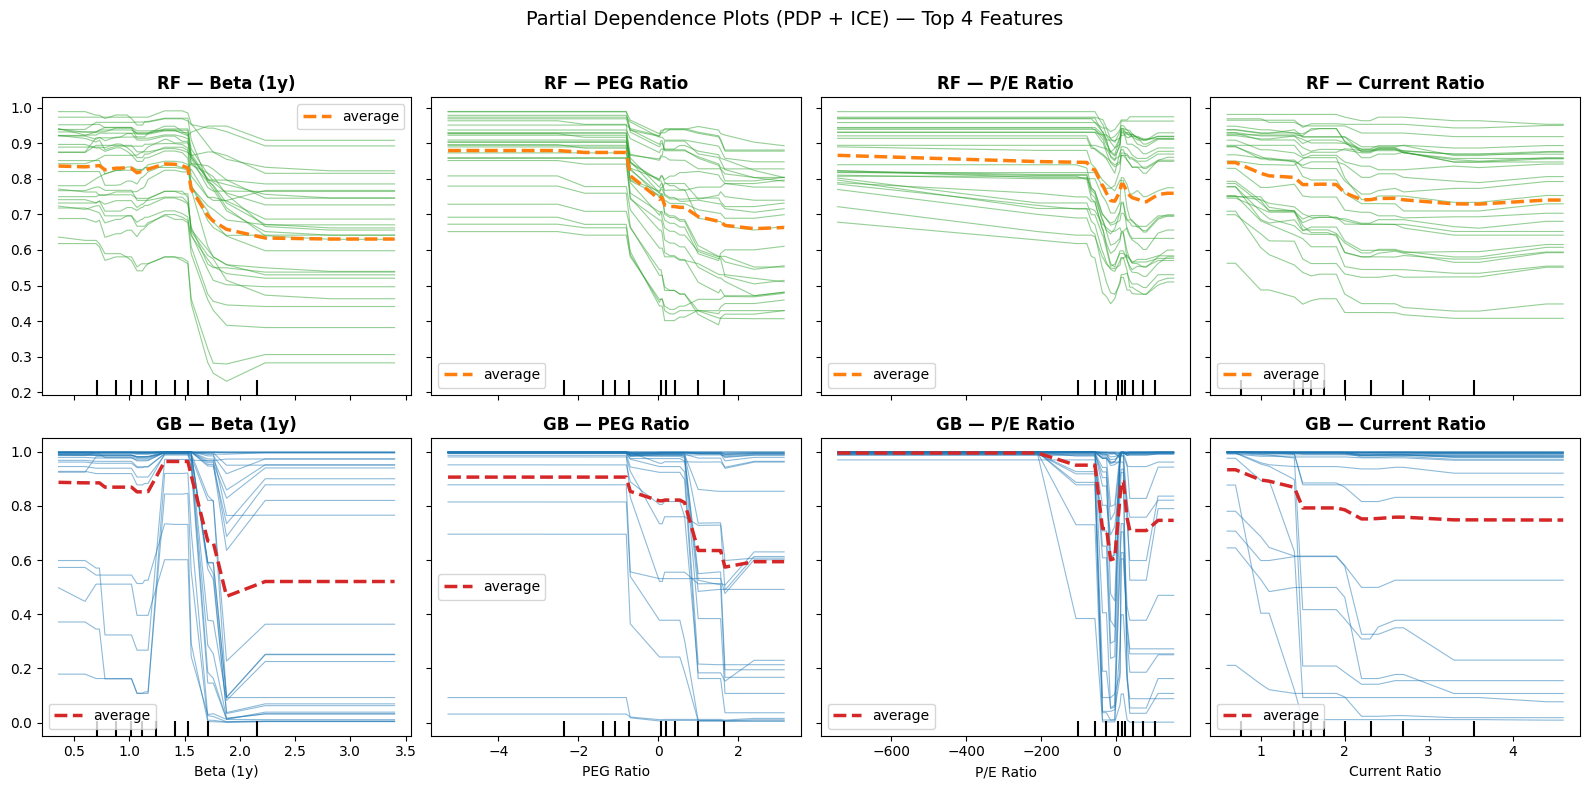

In [47]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Убедимся, что X_test — DataFrame 
if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test, columns=feature_cols)
else:
    X_test_df = X_test

# Топ-4 признака по совокупной важности (из их графиков важности признаков)
features_top4 = ['Beta (1y)', 'PEG Ratio', 'P/E Ratio', 'Current Ratio']

# Создаём фигуру: 2 строки (RF и GB), 4 столбца (признаки)
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex='col', sharey='row')

# Настройки стилей
ice_kw = {'color': 'tab:green', 'linewidth': 0.8, 'alpha': 0.5}
pd_kw = {'color': 'tab:orange', 'linestyle': '--', 'linewidth': 2.5}

# RF
PartialDependenceDisplay.from_estimator(
    rf, X_subset, features_top4,
    kind='both',
    random_state=42,
    ice_lines_kw=ice_kw,
    pd_line_kw=pd_kw,
    ax=axes[0]
)
for ax in axes[0]:
    ax.set_title(ax.get_title().replace('Partial dependence of ', ''), fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

# GB
PartialDependenceDisplay.from_estimator(
    gb, X_subset, features_top4,
    kind='both',
    random_state=42,
    ice_lines_kw={'color': 'tab:blue', 'linewidth': 0.8, 'alpha': 0.5},
    pd_line_kw={'color': 'tab:red', 'linestyle': '--', 'linewidth': 2.5},
    ax=axes[1]
)
for ax in axes[1]:
    ax.set_title(ax.get_title().replace('Partial dependence of ', ''), fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Подписи осей и заголовки
for col in range(4):
    axes[1, col].set_xlabel(features_top4[col])
    axes[0, col].set_title(f'RF — {features_top4[col]}', fontweight='bold')
    axes[1, col].set_title(f'GB — {features_top4[col]}', fontweight='bold')

plt.suptitle('Partial Dependence Plots (PDP + ICE) — Top 4 Features', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

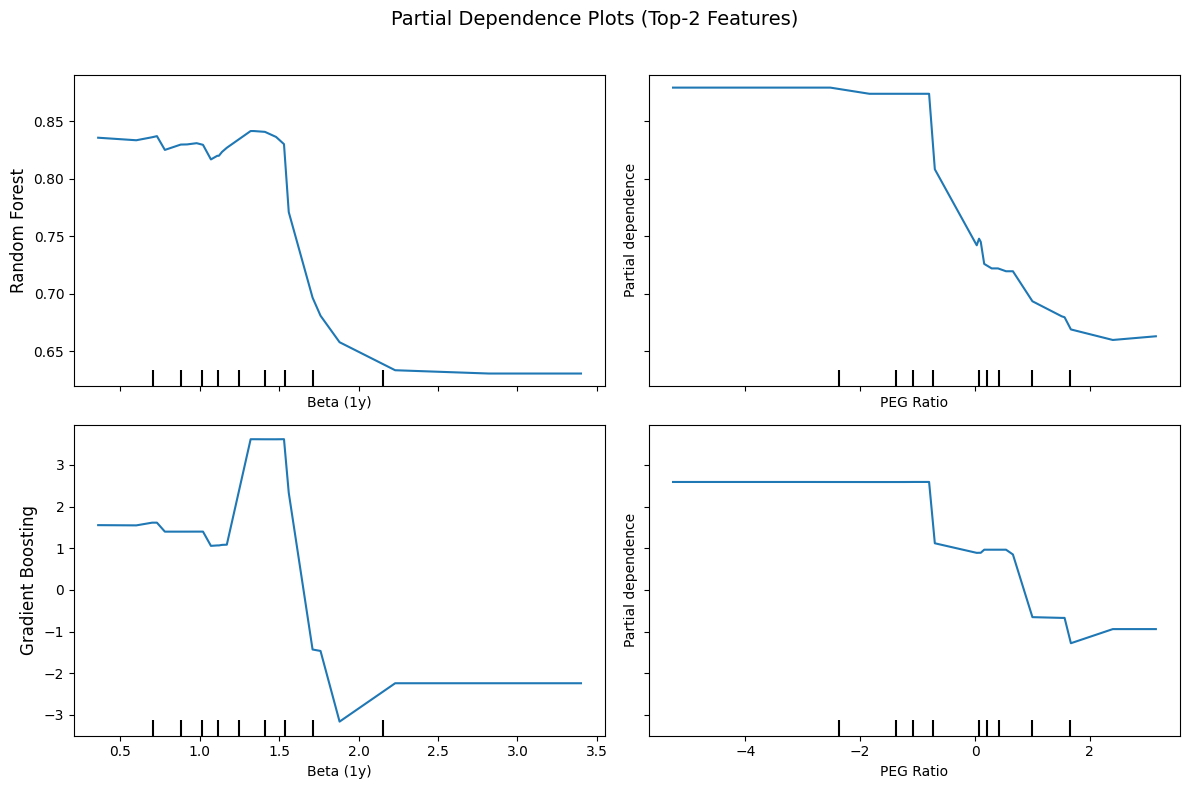

In [45]:
from sklearn.inspection import PartialDependenceDisplay

# Определим топ-2 признака (например, по RF)
rf_importances = rf.feature_importances_
top2_idx = np.argsort(rf_importances)[-2:][::-1]  # два самых важных
top2_features = [feature_cols[i] for i in top2_idx]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='row')
models_pdp = [("Random Forest", rf, X_test), ("Gradient Boosting", gb, X_test)]

for row, (name, model, X_t) in enumerate(models_pdp):
    PartialDependenceDisplay.from_estimator(
        model, X_t, top2_features,
        ax=axes[row], 
        grid_resolution=50
    )
    axes[row, 0].set_ylabel(name, fontsize=12)

# Подписи осей
for col in range(2):
    axes[1, col].set_xlabel(top2_features[col])

plt.suptitle('Partial Dependence Plots (Top-2 Features)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [49]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

X = final_df[feature_cols].values
y_clf = final_df['target'].values          # 0/1
y_reg = final_df['upside_numeric'].values  # например, +23.5, -15.2

# Масштабируем признаки (обязательно для нейросети!)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Разделим данные на train/test (с stratify для классификации)
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X_scaled, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)

_, _, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

# Вычисляем веса классов
class_weights = compute_class_weight('balanced', classes=np.unique(y_clf_train), y=y_clf_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Обучим бинарный классификатор
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

nn_clf = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
   # Dropout(0.3),
    Dense(32, activation='relu'),
   # Dropout(0.1),
    Dense(1, activation='sigmoid')  # ← бинарная классификация
])
nn_clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Обучаем с весами
history_clf = nn_clf.fit(
    X_train, y_clf_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict, 
    verbose=0
)

# Оценим Нейро Классификатор
from sklearn.metrics import classification_report, roc_auc_score

y_clf_pred = (nn_clf.predict(X_test) > 0.5).astype(int).flatten()
y_clf_proba = nn_clf.predict(X_test).flatten()

print("Neural Network Classifier")
print(classification_report(y_clf_test, y_clf_pred))
print(f"ROC-AUC: {roc_auc_score(y_clf_test, y_clf_proba):.4f}")

Class weights: {0: 2.725, 1: 0.6123595505617978}


2025-11-25 12:29:04.633181: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-25 12:29:04.660050: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-25 12:29:04.890728: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-25 12:29:04.893100: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-25 12:29:06.939582: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

1/1 [==============================] - 0s 29ms/step
Neural Network Classifier
              precision    recall  f1-score   support

           0       0.36      0.80      0.50         5
           1       0.94      0.70      0.80        23

    accuracy                           0.71        28
   macro avg       0.65      0.75      0.65        28
weighted avg       0.84      0.71      0.75        28

ROC-AUC: 0.7478


In [66]:
import shap

X_test_df = pd.DataFrame(X_test, columns=feature_cols)
# Для бинарной классификации: нас интересует класс 1 /// predict_proba[:, 1]
explainer_mlp = shap.Explainer(mlp_clf.predict_proba, X_test_df)
shap_values_mlp = explainer_mlp(X_test_df)

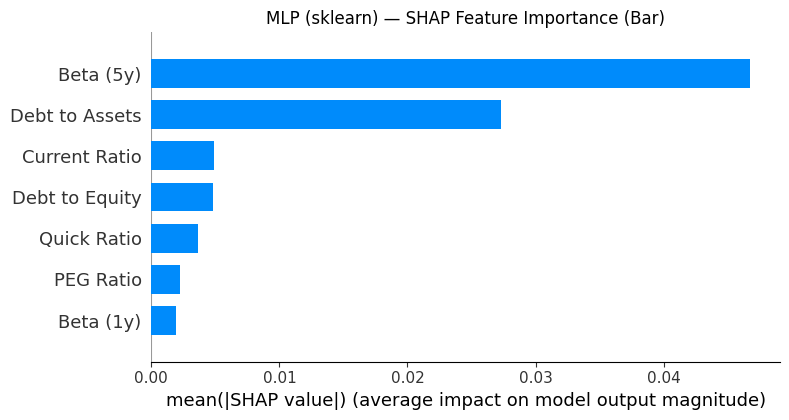

In [67]:
# Bar plot (важность признаков)
shap.summary_plot(shap_values_mlp[:, :, 1], X_test_df, plot_type="bar", max_display=7, show=False)
plt.title("MLP (sklearn) — SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.show()

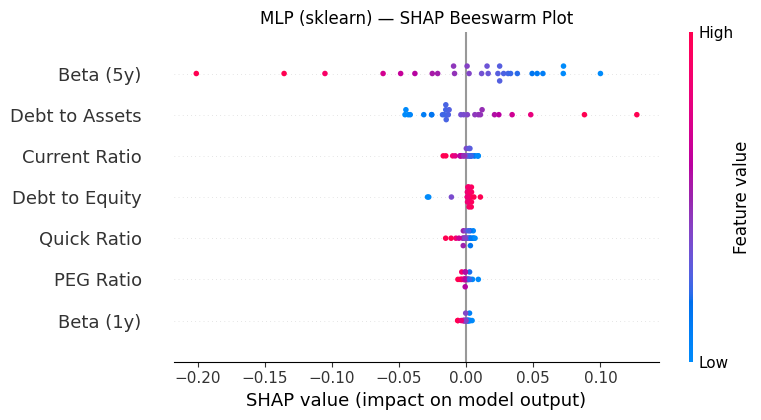

In [68]:
# Beeswarm plot (распределение SHAP значений)
shap.summary_plot(shap_values_mlp[:, :, 1], X_test_df, max_display=7, show=False)
plt.title("MLP (sklearn) — SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

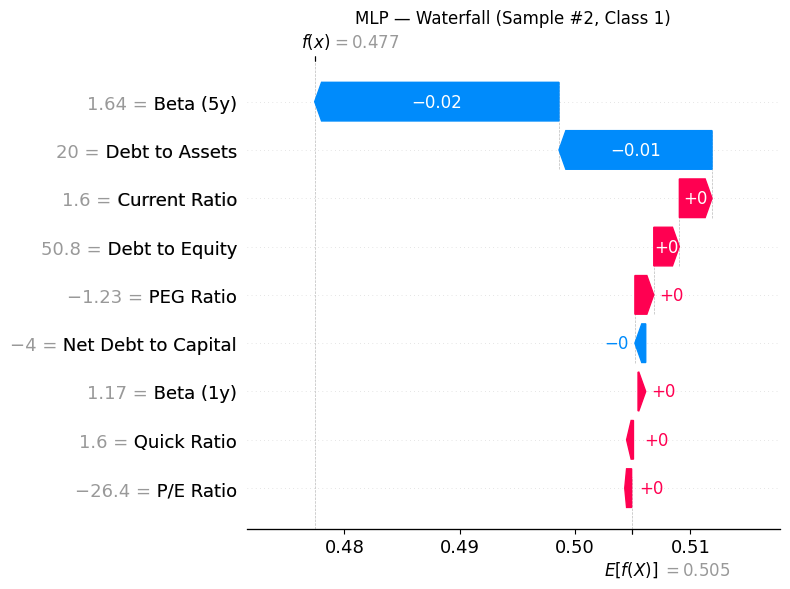

In [69]:
# Waterfall plot (для одного объекта, например, индекс 2)
shap.plots.waterfall(shap_values_mlp[2, :, 1], show=False)
plt.title("MLP — Waterfall (Sample #2, Class 1)")
plt.tight_layout()
plt.show()

In [70]:
# Force plot 
shap.initjs()
shap.plots.force(shap_values_mlp[0, :, 1])

In [76]:
# Настройки 
i = 8  # индекс объекта из X_test
model = mlp_clf  # ваша модель (MLPClassifier)

#  Подготовка X_test_df
if isinstance(X_test, pd.DataFrame):
    X_test_df = X_test
else:
    if 'feature_cols' not in globals():
        raise ValueError("X_test — массив, но не определён feature_cols")
    X_test_df = pd.DataFrame(X_test, columns=feature_cols)

# Расчёт SHAP-значений 
if 'shap_values_mlp' not in globals():
    explainer = shap.Explainer(model.predict_proba, X_test_df)
    shap_values_mlp = explainer(X_test_df)
    print("Готово!")

#  Информация об объекте 
y_true_i = y_clf_test[i]
y_pred_i = model.predict(X_test[i:i+1])[0]
y_proba_i = model.predict_proba(X_test[i:i+1])[0, 1]

print(f"\n🔹 Объект #{i} | Истинный класс: {y_true_i}")
print(f"🔹 Предсказание: {y_pred_i} (вероятность класса 1: {y_proba_i:.4f})")

# Значения признаков
sample_features = X_test_df.iloc[i]
display(pd.DataFrame(sample_features).T)

#  SHAP Force Plot 
shap.initjs()  
shap.plots.force(shap_values_mlp[i, :, 1])


🔹 Объект #8 | Истинный класс: 1
🔹 Предсказание: 1 (вероятность класса 1: 0.6023)


,P/E Ratio,PEG Ratio,Beta (5y),Beta (1y),Quick Ratio,Current Ratio,Debt to Equity,Debt to Assets,Net Debt to Capital
8,-66.7,-1.32,0.92,0.98,1.8,2.0,119.1,49.9,19.4


In [59]:
# Обучим силами skikit-learn
# --- 1. Подготовка данных (уже у вас есть) ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import shap

# Убедитесь, что final_df и feature_cols определены
X = final_df[feature_cols].values
y_clf = final_df['target'].values          # 0/1
y_reg = final_df['upside_numeric'].values  # числовой таргет

# Разделение (одинаковое для обеих задач)
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# --- 2. Нейросетевой бинарный классификатор (MLPClassifier) ---
mlp_clf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(32,),
        max_iter=200,
        random_state=42,
        alpha=0.05,
        solver='adam'
    ))
])

# Применяем балансировку через sample_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_clf_train), y=y_clf_train)
class_weight_dict = dict(enumerate(class_weights))

# Обучение с весами
mlp_clf.fit(X_train, y_clf_train, mlp__sample_weight=[class_weight_dict[y] for y in y_clf_train])

# Оценка
from sklearn.metrics import classification_report, roc_auc_score
y_pred = mlp_clf.predict(X_test)
y_proba = mlp_clf.predict_proba(X_test)[:, 1]

print("MLPClassifier (sklearn)")
print(classification_report(y_clf_test, y_pred))
print(f"ROC-AUC:, {roc_auc_score(y_clf_test, y_proba):.4f}")

MLPClassifier (sklearn)
              precision    recall  f1-score   support

           0       0.36      0.80      0.50         5
           1       0.94      0.70      0.80        23

    accuracy                           0.71        28
   macro avg       0.65      0.75      0.65        28
weighted avg       0.84      0.71      0.75        28

ROC-AUC:, 0.7739


PermutationExplainer explainer: 21it [00:12,  1.66it/s]                         


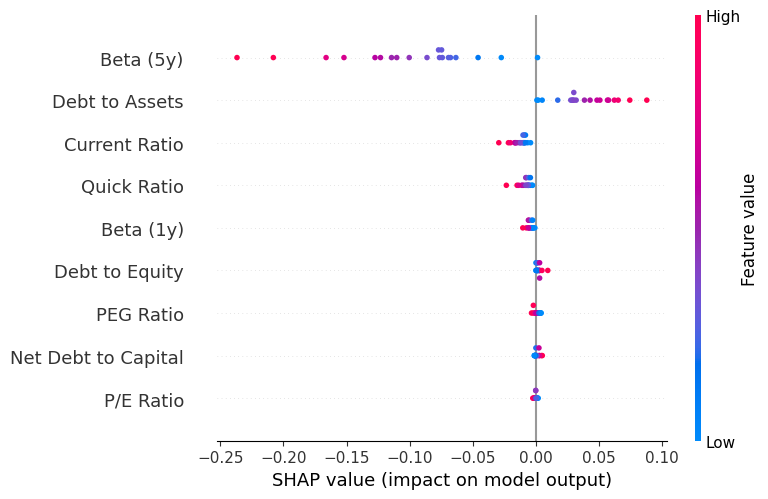

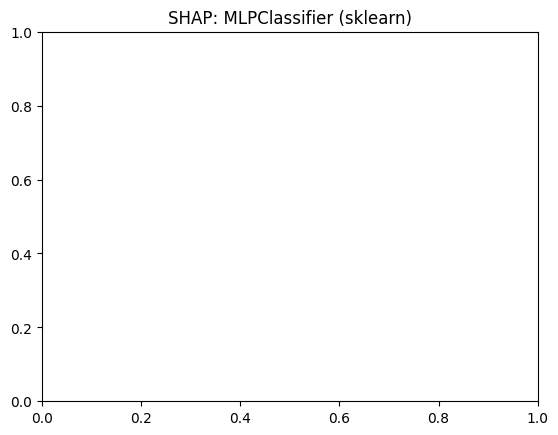


=== MLPRegressor (sklearn) ===
MAE: 17.929536735445975
R²: -0.02220548565219005


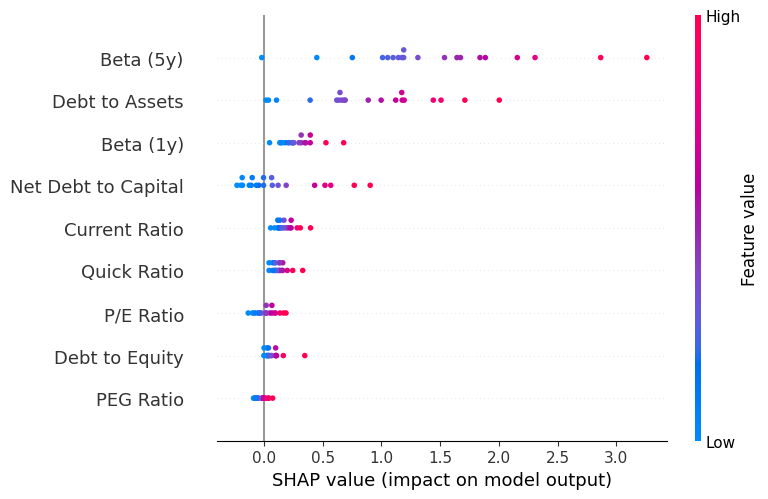

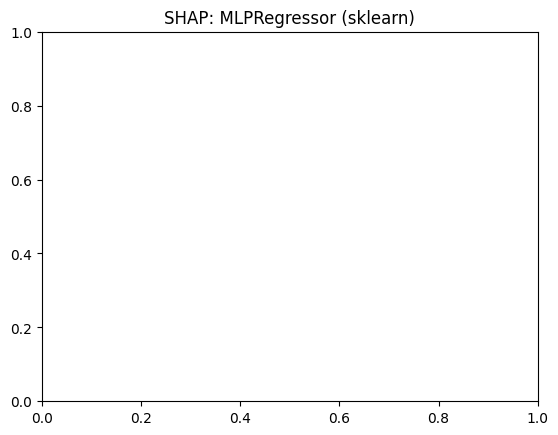

In [40]:
# --- 3. SHAP для классификатора ---
# Используем только масштабированные признаки из пайплайна
X_train_scaled = mlp_clf.named_steps['scaler'].transform(X_train)

explainer_clf = shap.PermutationExplainer(
    mlp_clf.predict_proba,
    X_train_scaled[:50],  # фон — 50 объектов
    feature_names=feature_cols
)
shap_values_clf = explainer_clf(X_test[:20])  # объясняем 20 тестовых примеров

# График
shap.summary_plot(shap_values_clf[:, :, 1], X_test[:20], feature_names=feature_cols)
plt.title("SHAP: MLPClassifier (sklearn)")
plt.show()

# --- 4. Нейросетевой регрессор (MLPRegressor) ---
mlp_reg = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(32,),
        max_iter=500,
        random_state=42,
        alpha=0.01,
        solver='adam'
    ))
])
mlp_reg.fit(X_train, y_reg_train)

# Оценка регрессора
from sklearn.metrics import mean_absolute_error, r2_score
y_reg_pred = mlp_reg.predict(X_test)
print("\n=== MLPRegressor (sklearn) ===")
print("MAE:", mean_absolute_error(y_reg_test, y_reg_pred))
print("R²:", r2_score(y_reg_test, y_reg_pred))

# --- 5. SHAP для регрессора ---
explainer_reg = shap.PermutationExplainer(
    mlp_reg.predict,
    X_train_scaled[:50],
    feature_names=feature_cols
)
shap_values_reg = explainer_reg(X_test[:20])

shap.summary_plot(shap_values_reg, X_test[:20], feature_names=feature_cols)
plt.title("SHAP: MLPRegressor (sklearn)")
plt.show()

Форма данных: (137, 9)
Распределение классов: [ 25 112]
Logistic Regression → Acc: 0.679, ROC-AUC: 0.774, F1 (macro): 0.620
Random Forest → Acc: 0.893, ROC-AUC: 0.748, F1 (macro): 0.755
Gradient Boosting → Acc: 0.786, ROC-AUC: 0.765, F1 (macro): 0.635


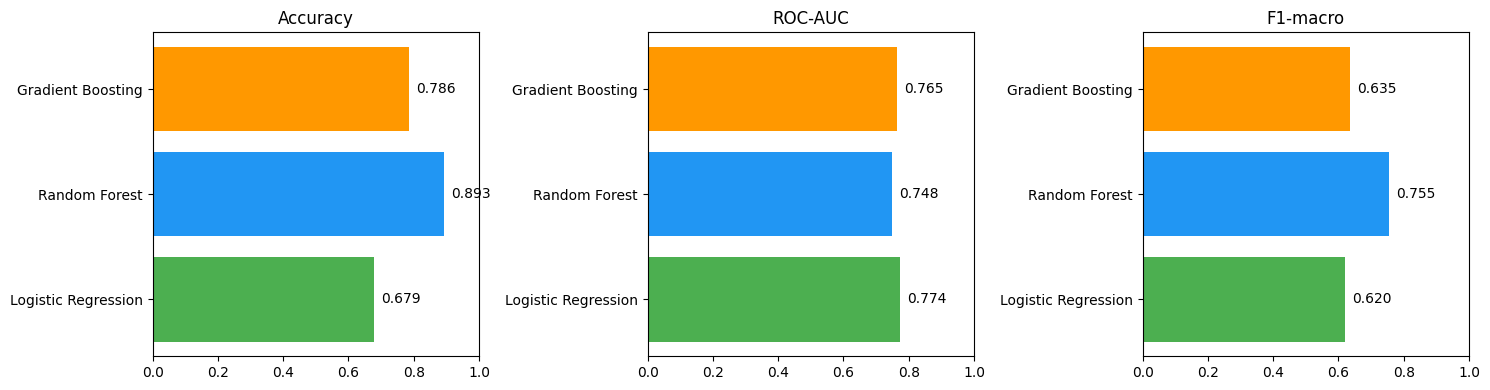


=== Logistic Regression ===


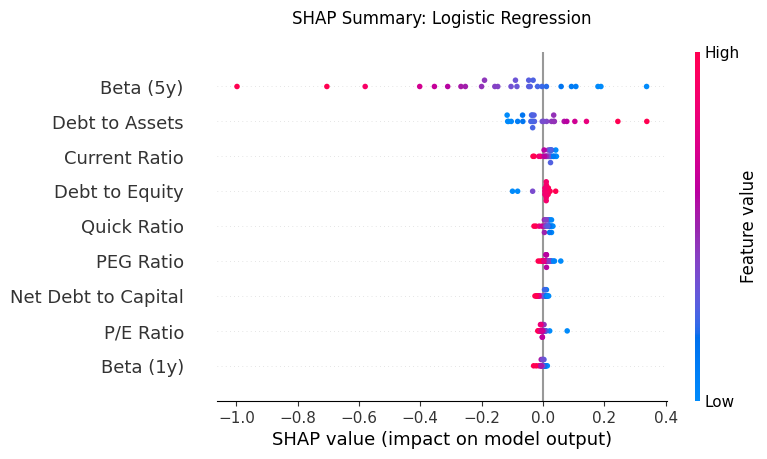


=== Random Forest ===


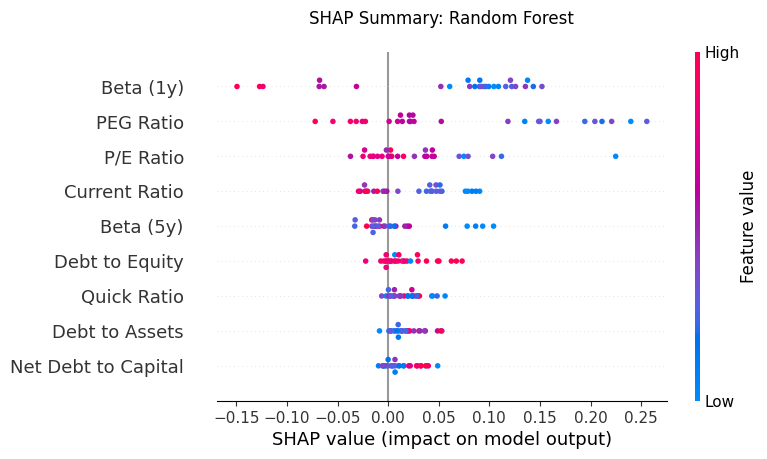


=== Gradient Boosting ===


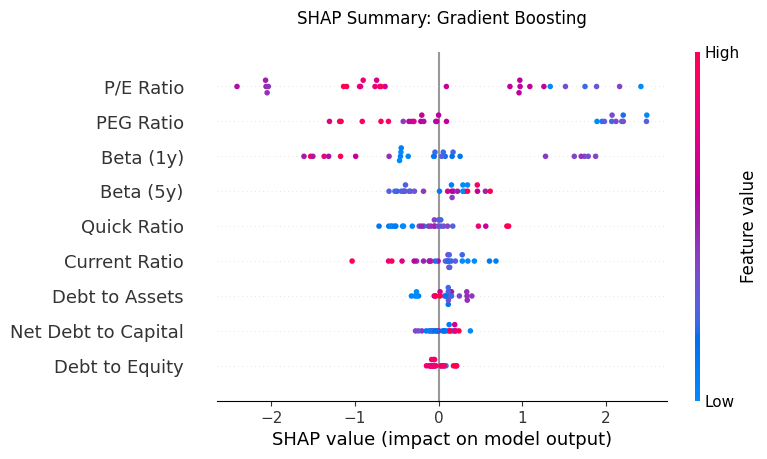

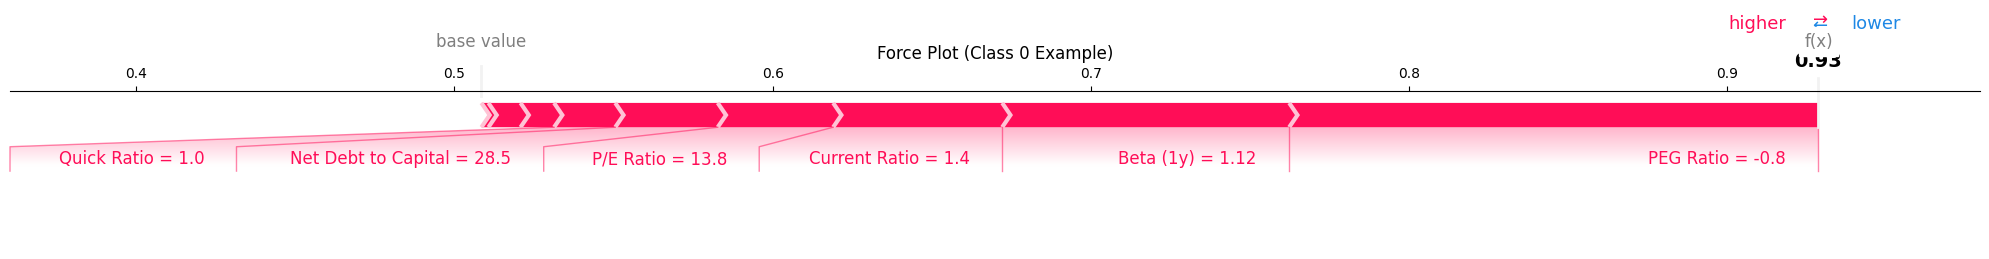

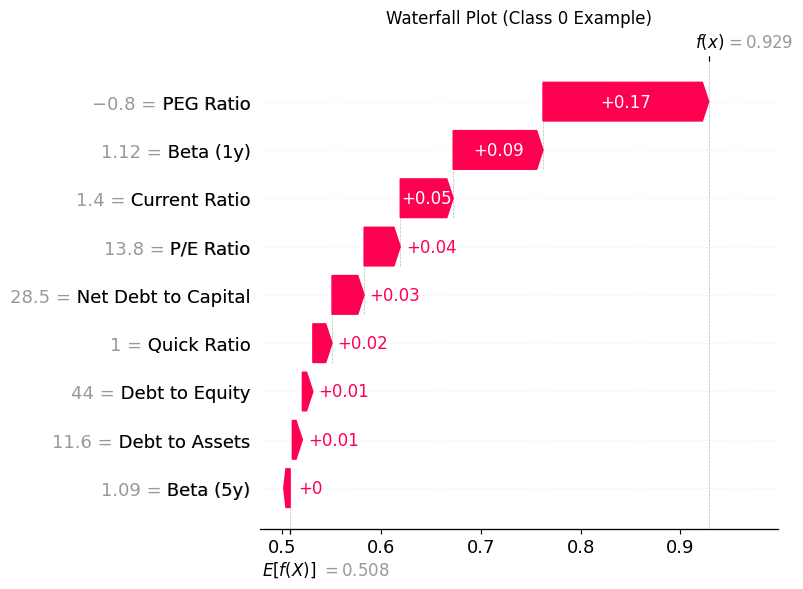

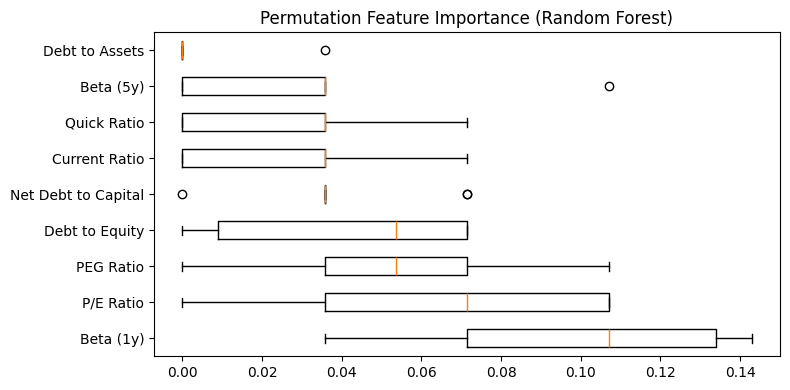

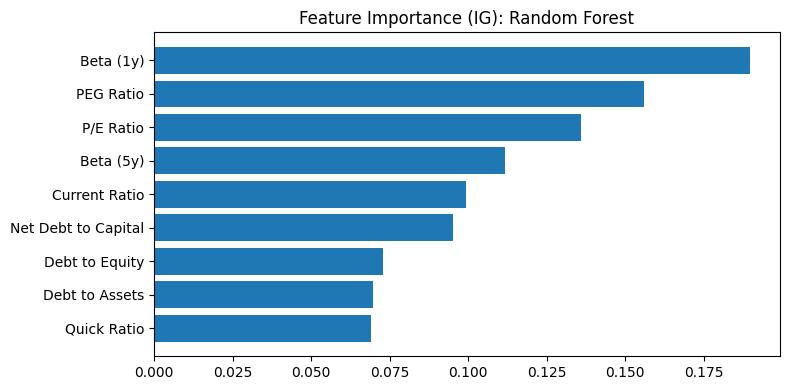

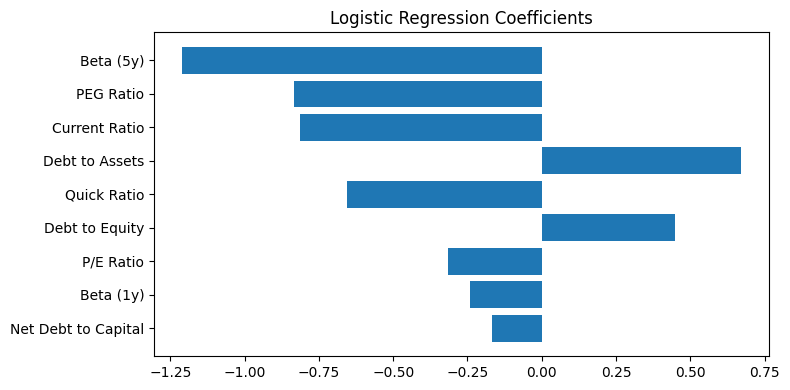

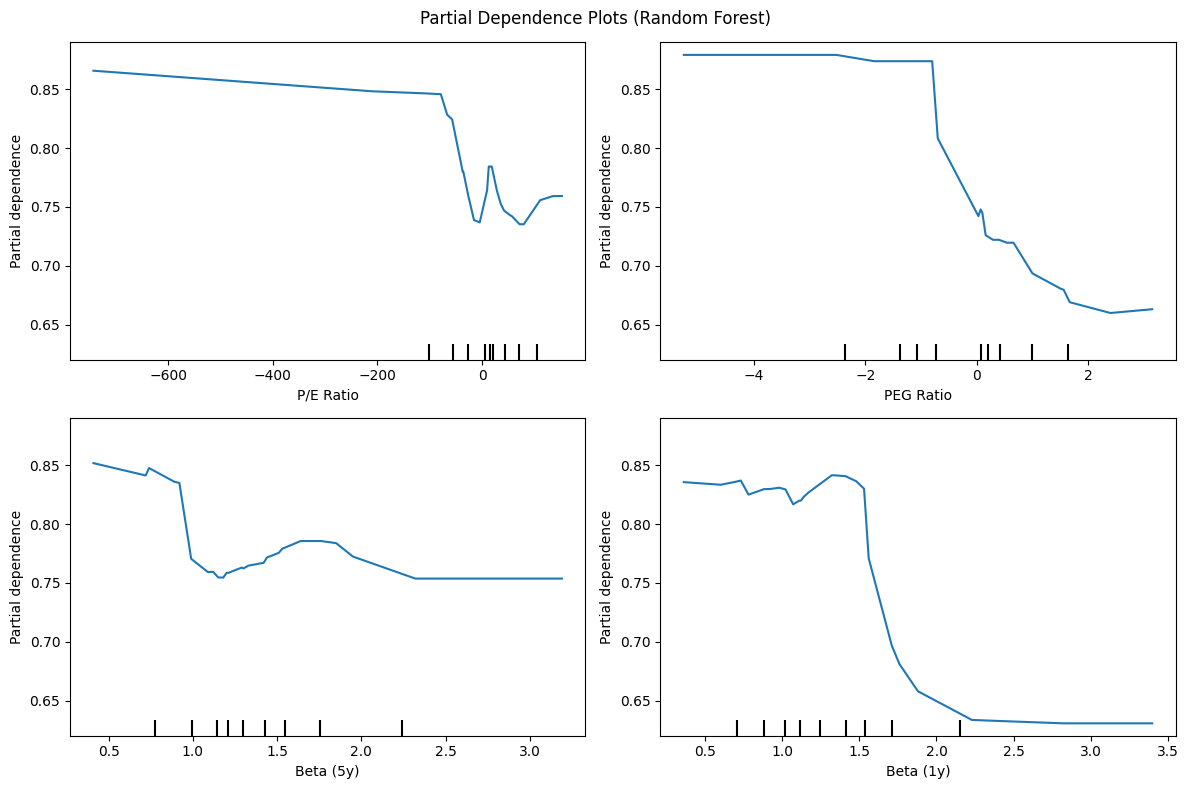

In [38]:
# Обучить классические модели на основе градиентного бустинга, случайного леса и логистической регрессии для задачи настройки бинарного классификатора


# 1. Импорты
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import shap
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

# 2. Загрузка и предобработка данных
df = pd.read_csv('NYSE.csv')


# Парсинг Analyst Target Upside
def parse_upside(val):
    if pd.isna(val): return np.nan
    s = str(val).strip()
    match = re.search(r'([+-]?\d*\.?\d+)', s)
    if not match: return np.nan
    num = float(match.group(1))
    return -abs(num) if 'Downside' in s else abs(num)

df['upside_numeric'] = df['Analyst Target Upside'].apply(parse_upside)
df['target'] = (df['upside_numeric'] > 0).astype(int)
df = df.dropna(subset=['upside_numeric']).reset_index(drop=True)

# Признаки
feature_cols = [
    'P/E Ratio', 'PEG Ratio', 'Beta (5y)', 'Beta (1y)',
    'Quick Ratio', 'Current Ratio',
    'Debt to Equity', 'Debt to Assets', 'Net Debt to Capital'
]

# Очистка признаков
def clean_numeric(val):
    if pd.isna(val) or str(val).strip() == 'blank': return np.nan
    s = re.sub(r'[^\d\.\+\-]', '', str(val))
    try:
        return float(s) if (s.count('+') + s.count('-') <= 1) else np.nan
    except:
        return np.nan

for col in feature_cols:
    df[col] = df[col].apply(clean_numeric)

# Финальная выборка
final_df = df.dropna(subset=feature_cols + ['target']).reset_index(drop=True)
X = final_df[feature_cols].values
y = final_df['target'].values.astype(int)

print("Форма данных:", X.shape)
print("Распределение классов:", np.bincount(y))

# 3. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Обучение моделей
# 4.1 Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 4.2 Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# 4.3 Gradient Boosting
sample_weight = compute_sample_weight('balanced', y_train)
gb = HistGradientBoostingClassifier(max_iter=100, max_depth=4, random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weight)

# 5. Оценка моделей
models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest': (rf, X_test),
    'Gradient Boosting': (gb, X_test)
}

results = []
for name, (model, X_t) in models.items():
    y_pred = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append([name, acc, auc, f1])
    print(f"{name} → Acc: {acc:.3f}, ROC-AUC: {auc:.3f}, F1 (macro): {f1:.3f}")

# 6. График метрик с подписями
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'ROC-AUC', 'F1-macro'])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(['Accuracy', 'ROC-AUC', 'F1-macro']):
    ax = axes[i]
    bars = ax.barh(results_df['Model'], results_df[metric], color=['#4CAF50', '#2196F3', '#FF9800'])
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    ax.bar_label(bars, fmt='%.3f', padding=5)
plt.tight_layout()
plt.show()

# 7. SHAP Summary Plot — Правильно, с max_display=9
explainer_rf = shap.Explainer(rf, X_train)
shap_values_rf = explainer_rf(X_test, check_additivity=False)

# --- SHAP Summary Plot для всех моделей ---
models_for_shap = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest': (rf, X_test),
    'Gradient Boosting': (gb, X_test)
}

for name, (model, X_t) in models_for_shap.items():
    print(f"\n=== {name} ===")
    
    if name == 'Logistic Regression':
        explainer = shap.LinearExplainer(model, X_train_scaled)
        shap_values = explainer.shap_values(X_t)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_t)
        
        # Обработка трёхмерного случая
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # класс 1
        elif shap_values.ndim == 3 and shap_values.shape[2] == 2:
            shap_values = shap_values[:, :, 1]

    # Построение графика
    shap.summary_plot(
        shap_values,
        X_t,
        feature_names=feature_cols,
        max_display=9,
        show=False
    )
    plt.title(f"SHAP Summary: {name}", fontsize=12, pad=20)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    
# 8. SHAP Force & Waterfall через TreeExplainer (надёжный способ)
explainer_old = shap.TreeExplainer(rf)
shap_values_old = explainer_old.shap_values(X_test)

# Обработка возможных форм
if isinstance(shap_values_old, list):
    shap_vals_class1 = shap_values_old[1]
else:
    # Если массив (n, n_features, 2)
    if shap_values_old.ndim == 3 and shap_values_old.shape[2] == 2:
        shap_vals_class1 = shap_values_old[:, :, 1]
    else:
        shap_vals_class1 = shap_values_old

# Пример из класса 0
idx_0_candidates = np.where(y_test == 0)[0]
if len(idx_0_candidates) == 0:
    raise ValueError("Нет примеров с таргетом = 0 в тесте!")
idx_0 = idx_0_candidates[0]

# Базовое значение
expected_val = explainer_old.expected_value
base_value = expected_val[1] if not np.isscalar(expected_val) else expected_val

# Force Plot
shap.force_plot(
    base_value=base_value,
    shap_values=shap_vals_class1[idx_0],
    features=X_test[idx_0],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title("Force Plot (Class 0 Example)")
plt.tight_layout()
plt.show()

# Waterfall Plot
exp = shap.Explanation(
    values=shap_vals_class1[idx_0],
    base_values=base_value,
    data=X_test[idx_0],
    feature_names=feature_cols
)
shap.plots.waterfall(exp, max_display=9, show=False)
plt.title("Waterfall Plot (Class 0 Example)")
plt.tight_layout()
plt.show()

# 9. Permutation Importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm.importances_mean.argsort()[::-1]

plt.figure(figsize=(8, 4))
plt.boxplot(perm.importances[sorted_idx].T, vert=False, labels=np.array(feature_cols)[sorted_idx])
plt.title("Permutation Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

# 10. Feature Importance (IG)
importances = rf.feature_importances_
sorted_idx = importances.argsort()[::-1]

plt.figure(figsize=(8, 4))
plt.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx])
plt.gca().invert_yaxis()
plt.title("Feature Importance (IG): Random Forest")
plt.tight_layout()
plt.show()

# 11. Коэффициенты логистической регрессии
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': lr.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(coef_df['feature'], coef_df['coef'])
plt.gca().invert_yaxis()
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

# 12. Partial Dependence Plots
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
features_to_plot = [0, 1, 2, 3]  # первые 4 признака
PartialDependenceDisplay.from_estimator(
    rf, X_test, features_to_plot,
    feature_names=feature_cols,
    ax=ax.ravel()[:4]
)
plt.suptitle("Partial Dependence Plots (Random Forest)")
plt.tight_layout()
plt.show()

In [50]:
def clean_market_cap(val):
    if pd.isna(val): return np.nan
    s = str(val).replace('$', '').strip()
    if 'B' in s:
        return float(s.replace('B', '')) * 1e9
    elif 'M' in s:
        return float(s.replace('M', '')) * 1e6
    else:
        try:
            return float(s)
        except:
            return np.nan

df['mc_clean'] = df['Market Cap'].apply(clean_market_cap)

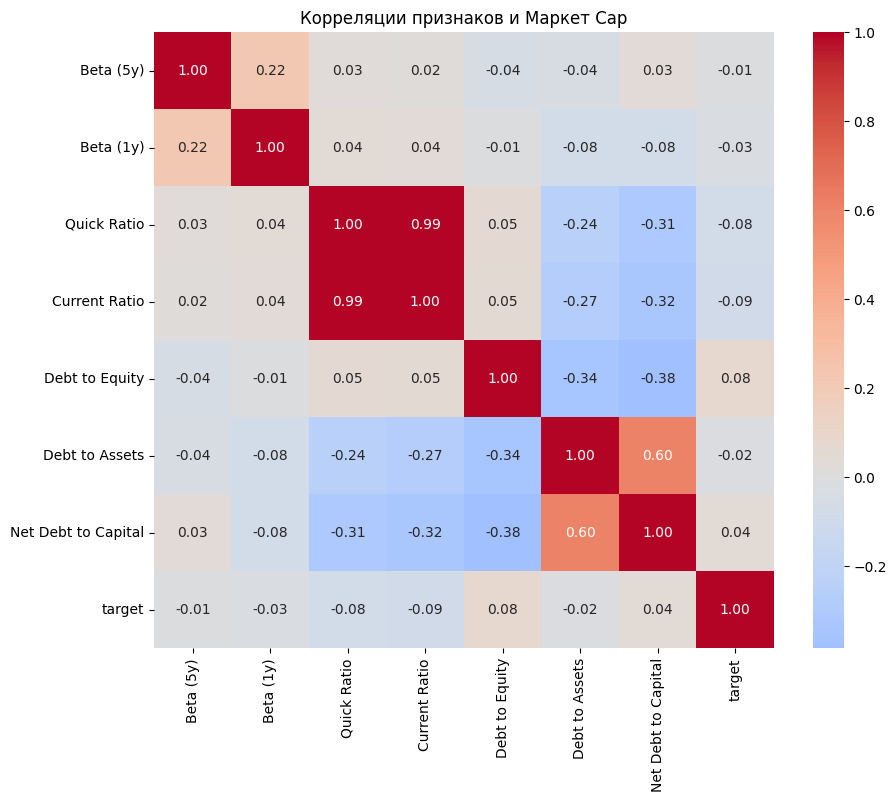

Корреляции с Маркет Cap:
Current Ratio         -0.086404
Quick Ratio           -0.082574
Debt to Equity         0.075844
Net Debt to Capital    0.040870
Beta (1y)             -0.025107
Debt to Assets        -0.020876
Beta (5y)             -0.005816
Name: target, dtype: float64


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Подготовка данных
df_clean = df.dropna(subset=['mc_clean'] + feature_cols).reset_index(drop=True)
X_num = df_clean[feature_cols].copy()
X_num['target'] = df_clean['mc_clean']

# Матрица корреляций
corr_matrix = X_num.corr()

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Корреляции признаков и Маркет Cap")
plt.show()

# Корреляции с целевой переменной
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print("Корреляции с Маркет Cap:")
print(target_corr)

Количество наблюдений после очистки PEG Ratio: 143
Финальная форма данных: (137, 7)
Примеры PEG Ratio: [ 0.22  0.1  -5.26  0.15  0.99]

=== Кросс-валидация (5-Fold) ===
Random Forest Regressor → MAE: 4.756 ± 1.553, R²: -1.215 ± 1.635
Gradient Boosting Regressor → MAE: 5.427 ± 1.666, R²: -1.185 ± 1.241

=== Обучение на полных данных (для интерпретации) ===
Random Forest Regressor — обучена
Gradient Boosting Regressor — обучена


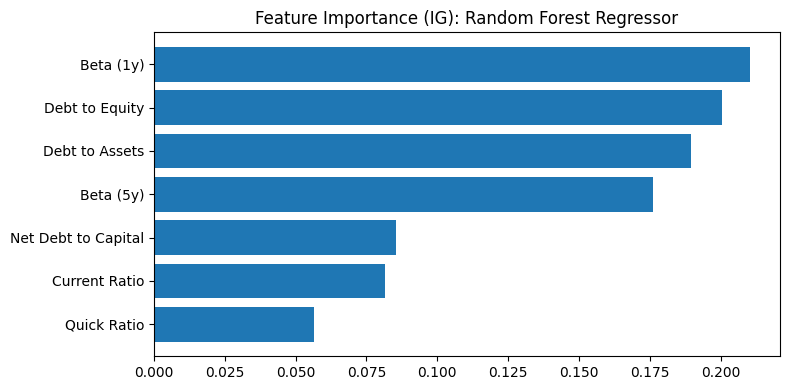

⚠️ Gradient Boosting Regressor: атрибут важности не найден


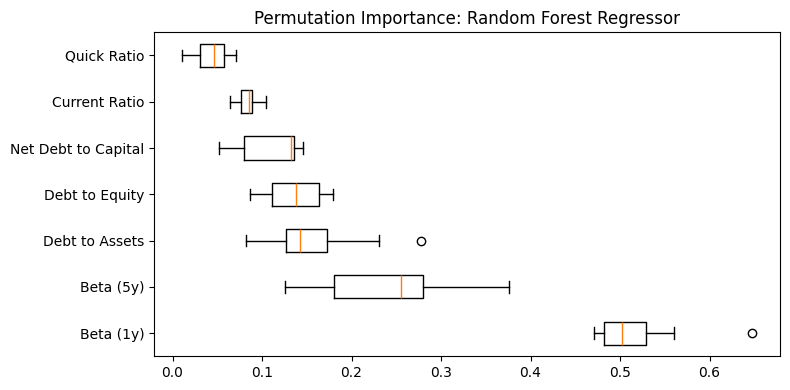

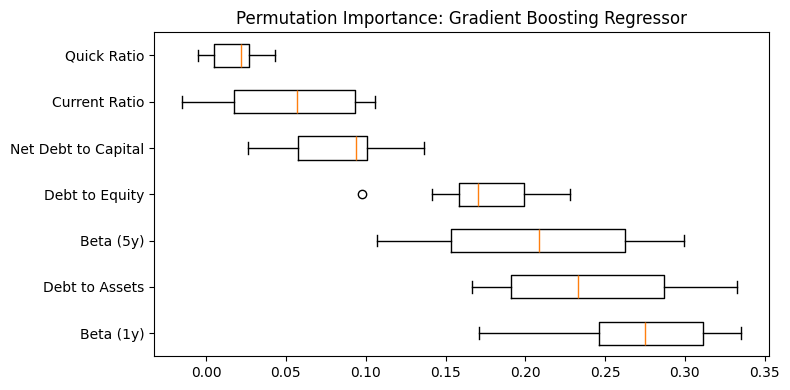

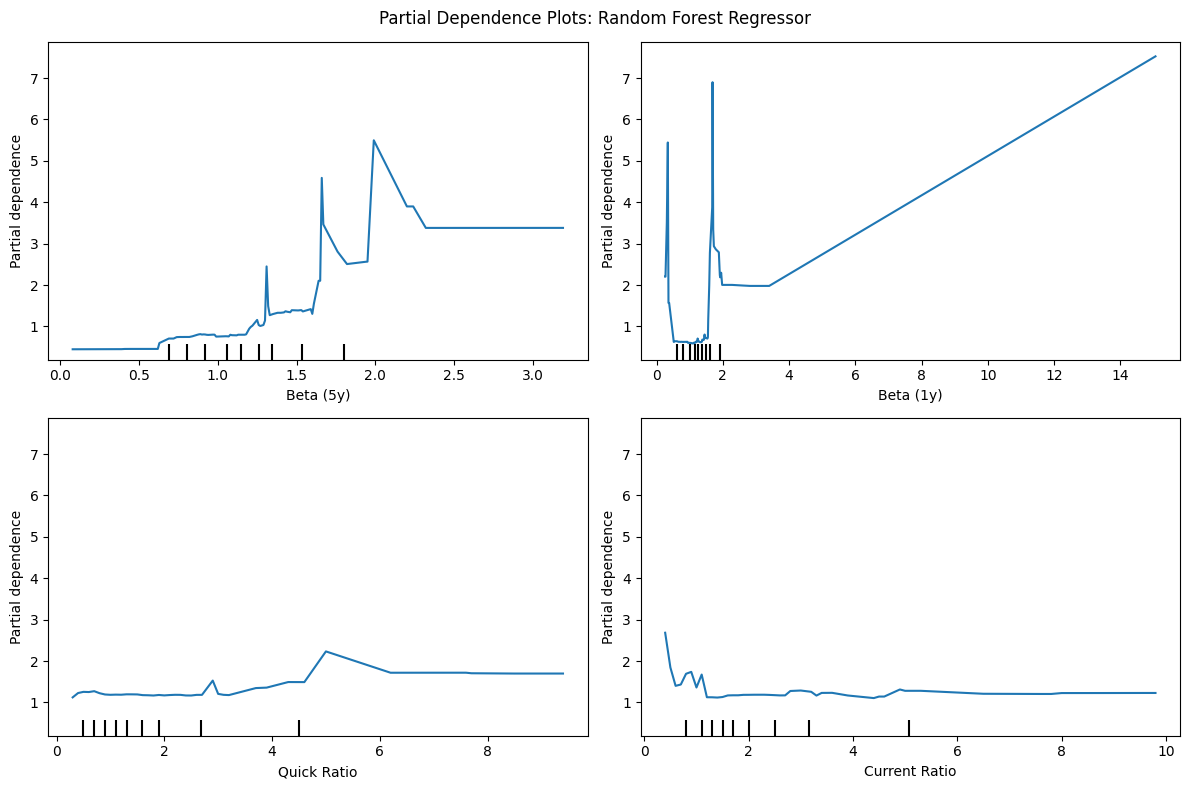

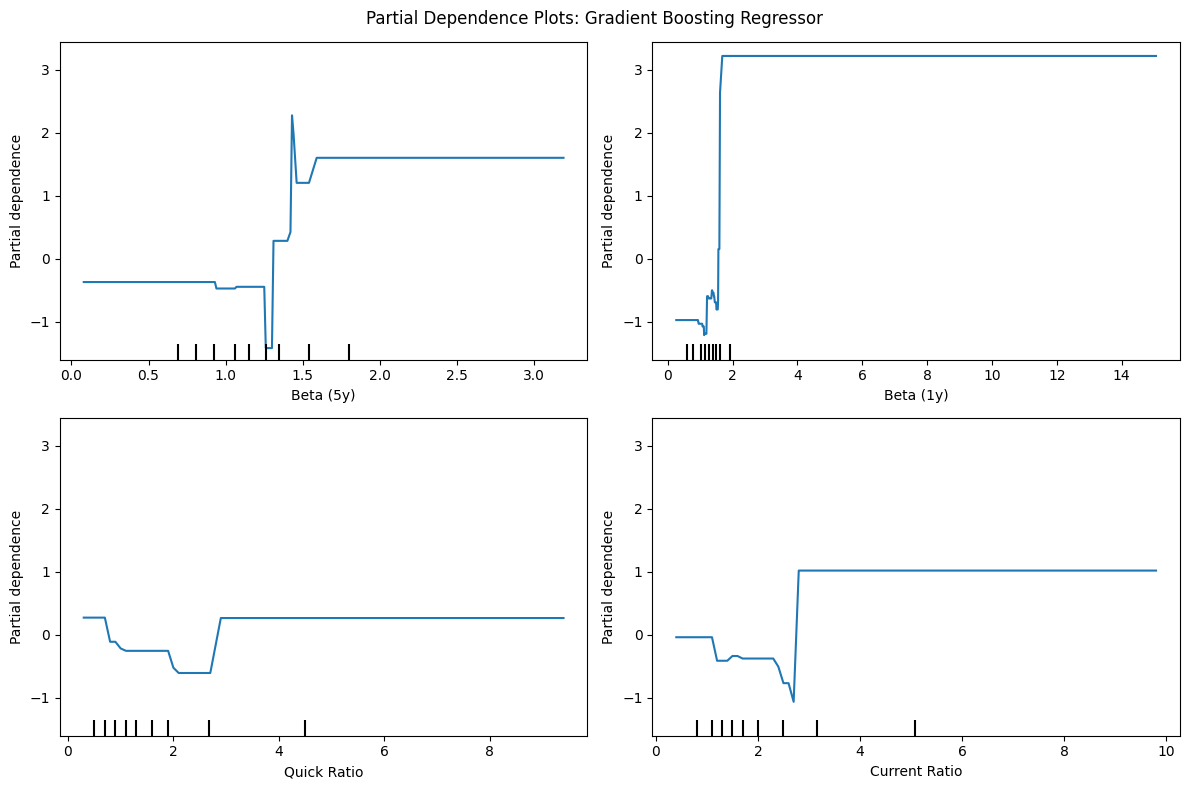

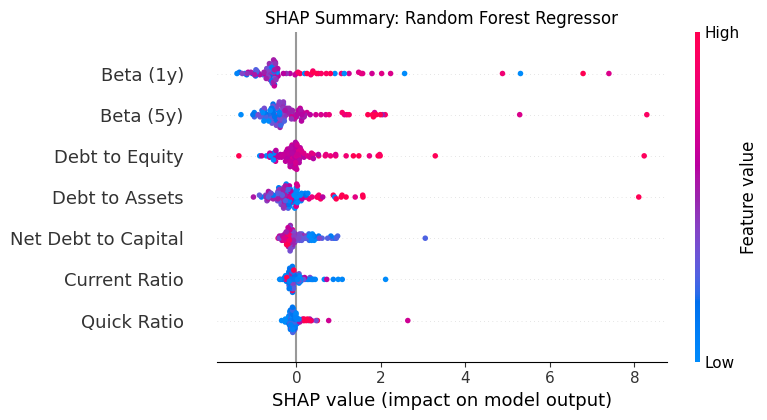

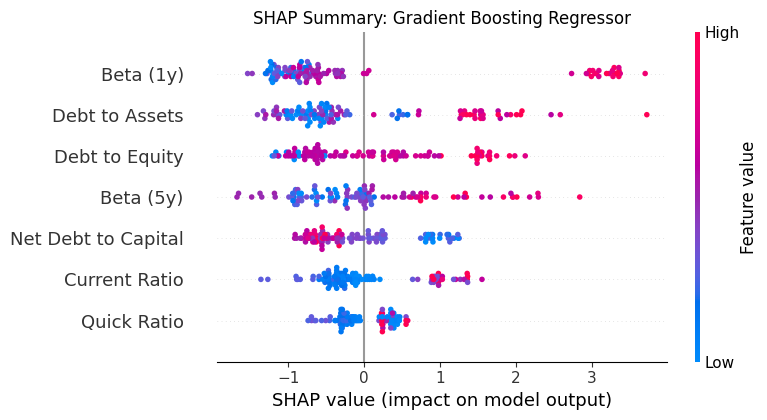

In [47]:
# 1. Импорты
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import shap

# 2. Загрузка данных
df = pd.read_csv('NYSE.csv')


# 3. Очистка PEG Ratio — оставляем только числовые значения
def clean_peg(val):
    if pd.isna(val) or str(val).strip() in ['blank', '-', '']:
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

df['PEG_Ratio_clean'] = df['PEG Ratio'].apply(clean_peg)
df = df.dropna(subset=['PEG_Ratio_clean']).reset_index(drop=True)

print("Количество наблюдений после очистки PEG Ratio:", len(df))

# 4. Признаки (исключаем PEG Ratio и P/E Ratio, чтобы избежать утечки)
feature_cols = [
    'Beta (5y)', 'Beta (1y)',
    'Quick Ratio', 'Current Ratio',
    'Debt to Equity', 'Debt to Assets', 'Net Debt to Capital'
]

# 5. Очистка признаков
def clean_numeric(val):
    if pd.isna(val) or str(val).strip() in ['blank', '-', '']:
        return np.nan
    s = re.sub(r'[^\d\.\+\-]', '', str(val))
    try:
        return float(s) if (s.count('+') + s.count('-') <= 1) else np.nan
    except:
        return np.nan

for col in feature_cols:
    df[col] = df[col].apply(clean_numeric)

# 6. Финальная выборка
final_df = df.dropna(subset=feature_cols + ['PEG_Ratio_clean']).reset_index(drop=True)
X = final_df[feature_cols].values
y = final_df['PEG_Ratio_clean'].values

print("Финальная форма данных:", X.shape)
print("Примеры PEG Ratio:", y[:5])

# 7. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Обучение моделей
models_reg = {
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42),
    'Gradient Boosting Regressor': HistGradientBoostingRegressor(max_iter=100, max_depth=4, random_state=42)
}

# 9. Кросс-валидация (5-Fold)
print("\n=== Кросс-валидация (5-Fold) ===")
cv = KFold(n_splits=5, shuffle=True, random_state=42)
results_reg = []

for name, model in models_reg.items():
    mae_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
    mae_mean, mae_std = mae_scores.mean(), mae_scores.std()
    r2_mean, r2_std = r2_scores.mean(), r2_scores.std()
    results_reg.append([name, mae_mean, mae_std, r2_mean, r2_std])
    print(f"{name} → MAE: {mae_mean:.3f} ± {mae_std:.3f}, R²: {r2_mean:.3f} ± {r2_std:.3f}")

# 10. Обучение на полных данных для интерпретации
print("\n=== Обучение на полных данных (для интерпретации) ===")
trained_models = {}
for name, model in models_reg.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} — обучена")

# 11. Feature Importance (IG)
for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'feature_importances'):
        importances = model.feature_importances
    else:
        print(f"⚠️ {name}: атрибут важности не найден")
        continue
    sorted_idx = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 4))
    plt.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx])
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance (IG): {name}")
    plt.tight_layout()
    plt.show()

# 12. Permutation Importance
X_sample, y_sample = X_train[:100], y_train[:100]
for name, model in trained_models.items():
    perm = permutation_importance(model, X_sample, y_sample, n_repeats=10, random_state=42)
    sorted_idx = perm.importances_mean.argsort()[::-1]
    plt.figure(figsize=(8, 4))
    plt.boxplot(perm.importances[sorted_idx].T, vert=False, labels=np.array(feature_cols)[sorted_idx])
    plt.title(f"Permutation Importance: {name}")
    plt.tight_layout()
    plt.show()

# 13. Partial Dependence Plots
for name, model in trained_models.items():
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    features_to_plot = [0, 1, 2, 3]  # первые 4 признака
    PartialDependenceDisplay.from_estimator(
        model, X_train, features_to_plot,
        feature_names=feature_cols,
        ax=ax.ravel()[:4]
    )
    plt.suptitle(f"Partial Dependence Plots: {name}")
    plt.tight_layout()
    plt.show()

# 14. SHAP Summary Plot
for name, model in trained_models.items():
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train[:200])
    shap.summary_plot(
        shap_values,
        X_train[:200],
        feature_names=feature_cols,
        max_display=7,
        show=False
    )
    plt.title(f"SHAP Summary: {name}")
    plt.tight_layout()
    plt.show()

In [9]:
df.head(15)

,Company,Name,Exchange,Sector,Industry,Market Cap,P/E Ratio,PEG Ratio,Last Trade Price,Day Change (%),...,Symbol,Beta (5y),Beta (1y),Quick Ratio,Current Ratio,Debt to Equity,Debt to Assets,Net Debt to Capital,upside_numeric,target
0,PBI,Pitney Bowes,NYSE,Technology,Office Equipment,$1.91B,24.5,0.22,$11.12,-1.30%,...,PBI,1.26,1.35,0.3,0.8,-377.1,62.5,43.5,52.9,1
1,CXM,Sprinklr,NYSE,Technology,Software & IT Services,$1.90B,17.3,0.10,$7.77,0.40%,...,CXM,0.78,0.95,1.4,1.6,8.9,4.4,-21.6,15.7,1
2,DV,DoubleVerify Holdings,NYSE,Technology,Software & IT Services,$1.85B,35.7,-5.26,$11.28,-0.40%,...,DV,0.99,1.07,3.9,4.4,9.5,8.0,-5.5,63.1,1
3,FINV,FinVolution Group,NYSE,Technology,Financial Technology (Fintech) & Infrastructure,$1.83B,5.1,0.15,$7.22,-5.40%,...,FINV,0.41,0.62,5.0,9.7,7.0,4.4,-44.7,53.5,1
4,RAMP,Liveramp,NYSE,Technology,Software & IT Services,$1.80B,142.8,0.99,$27.41,1.80%,...,RAMP,0.90,1.07,2.7,2.8,3.7,2.8,-17.9,45.9,1
5,VYX,NCR,NYSE,Technology,Software & IT Services,$1.77B,-24.1,-0.08,$12.77,1.40%,...,VYX,1.82,1.23,0.7,1.2,117.0,33.6,31.6,25.3,1
6,ACVA,ACV Auctions,NYSE,Technology,Software & IT Services,$1.74B,-26.4,-1.23,$10.12,0.20%,...,ACVA,1.64,1.17,1.6,1.6,50.8,20.0,-4.0,77.9,1
7,ALIT,Alight,NYSE,Technology,Software & IT Services,$1.73B,-1.6,0.01,$3.27,1.90%,...,ALIT,1.13,1.22,0.7,1.2,68.7,31.6,49.2,143.9,1
8,SHCO,Soho House,NYSE,Technology,Software & IT Services,$1.73B,-29.2,-0.44,$8.86,0%,...,SHCO,0.69,1.23,0.4,0.7,-701.7,93.6,54.8,1.6,1
9,COUR,Coursera,NYSE,Technology,Software & IT Services,$1.68B,-32.5,-0.77,$10.25,-8.60%,...,COUR,1.40,1.55,2.4,2.5,0.8,0.5,-40.0,16.7,1


### Целевая переменная: Analyst Target Upside ----> преобразуем в бинарную метку (1 если > 0%, 0 если <= 0%).
#### Признаки: Используем числовые столбцы: P/E Ratio, PEG Ratio, Beta (5y), Quick Ratio, Current Ratio, Debt to Equity, Debt to Assets, Net Debt to Capital.
#### Не используем: Company Name, Exchange, Sector, Industry, Market Cap, Last Trade Price, Day Change (%) - либо категориальные, либо не несут прогностической информации для этой задачи.


In [6]:
df.head()

,Company,Name,Exchange,Sector,Industry,Market Cap,P/E Ratio,PEG Ratio,Last Trade Price,Day Change (%),Analyst Target Upside,Name.1,Symbol,Beta (5y),Beta (1y),Quick Ratio,Current Ratio,Debt to Equity,Debt to Assets,Net Debt to Capital
0,PBI,Pitney Bowes,NYSE,Technology,Office Equipment,$1.91B,24.5x,0.22,$11.12,-1.30%,52.9% Upside,Pitney Bowes,PBI,1.26,1.35,0.3x,0.8x,-377.10%,62.50%,43.50%
1,CXM,Sprinklr,NYSE,Technology,Software & IT Services,$1.90B,17.3x,0.10,$7.77,0.40%,15.7% Upside,Sprinklr,CXM,0.78,0.95,1.4x,1.6x,8.90%,4.40%,-21.60%
2,DV,DoubleVerify Holdings,NYSE,Technology,Software & IT Services,$1.85B,35.7x,-5.26,$11.28,-0.40%,63.1% Upside,DoubleVerify Holdings,DV,0.99,1.07,3.9x,4.4x,9.50%,8%,-5.50%
3,FINV,FinVolution Group,NYSE,Technology,Financial Technology (Fintech) & Infrastructure,$1.83B,5.1x,0.15,$7.22,-5.40%,53.5% Upside,FinVolution Group,FINV,0.41,0.62,5x,9.7x,7%,4.40%,-44.70%
4,RAMP,Liveramp,NYSE,Technology,Software & IT Services,$1.80B,142.8x,0.99,$27.41,1.80%,45.9% Upside,Liveramp,RAMP,0.9,1.07,2.7x,2.8x,3.70%,2.80%,-17.90%


In [5]:
df = pd.read_csv('NYSE.csv')

In [7]:
df.shape

(152, 20)

In [8]:
df.describe()

,PEG Ratio
count,143.000000
mean,1.382867
std,9.110097
min,-43.290000
25%,-0.730000
50%,0.140000
75%,1.035000
max,52.030000


In [9]:
# Функция очистки данных (из Задания 1)
def clean_ratio(series):
    return (
        series
        .astype(str)
        .str.replace('x', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace(', ', '.', regex=False)
        .replace(['-', 'N/A', '', 'nan'], np.nan)
        .str.strip()
    )

# Применяем очистку
df['P/E Ratio'] = clean_ratio(df['P/E Ratio'])
df['PEG Ratio'] = clean_ratio(df['PEG Ratio'])
df['Debt to Equity'] = clean_ratio(df['Debt to Equity'])
df['Debt to Assets'] = clean_ratio(df['Debt to Assets'])

df['P/E Ratio'] = pd.to_numeric(df['P/E Ratio'], errors='coerce')
df['PEG Ratio'] = pd.to_numeric(df['PEG Ratio'], errors='coerce')
df['Debt to Equity'] = pd.to_numeric(df['Debt to Equity'], errors='coerce')
df['Debt to Assets'] = pd.to_numeric(df['Debt to Assets'], errors='coerce')

# Формируем две независимые выборки из Задания 1
df1 = df[['Company', 'Debt to Equity', 'Debt to Assets']].dropna().reset_index(drop=True)
df2 = df[['Company', 'P/E Ratio', 'PEG Ratio']].dropna().reset_index(drop=True)

print(f"Выборка 1 (Debt): {len(df1)} компаний")
print(f"Выборка 2 (P/E & PEG): {len(df2)} компаний")

Выборка 1 (Debt): 150 компаний
Выборка 2 (P/E & PEG): 142 компаний


In [10]:
df1.describe()

,Debt to Equity,Debt to Assets
count,150.000000,150.000000
mean,-59.794667,27.074667
std,597.452574,25.304981
min,-4084.600000,0.000000
25%,3.800000,4.475000
50%,32.550000,23.150000
75%,91.950000,38.400000
max,959.900000,150.400000


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company         150 non-null    object 
 1   Debt to Equity  150 non-null    float64
 2   Debt to Assets  150 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.6+ KB


In [12]:
df2.describe()

,P/E Ratio,PEG Ratio
count,142.000000,142.000000
mean,10.094366,1.697465
std,198.052012,8.326412
min,-810.500000,-24.400000
25%,-25.725000,-0.715000
50%,15.850000,0.140000
75%,34.000000,1.052500
max,982.900000,52.030000


In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Company    142 non-null    object 
 1   P/E Ratio  142 non-null    float64
 2   PEG Ratio  142 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.5+ KB


In [ ]:
import pandas as pd
import numpy as np

# 1. Загрузка данных
df = pd.read_csv('NYSE_lab_01.xlsx')

# 2. Преобразование Analyst Target Upside в числовой формат
def parse_upside(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if 'Downside' in val:
        # Убираем всё, кроме числа
        num = val.replace('% Downside', '').replace('%', '').strip()
        return -float(num) if num.replace('.', '', 1).isdigit() else np.nan
    elif 'Upside' in val:
        num = val.replace('% Upside', '').replace('%', '').strip()
        return float(num) if num.replace('.', '', 1).isdigit() else np.nan
    else:
        # Если просто число или что-то непонятное — попытка преобразовать
        try:
            return float(val)
        except:
            return np.nan

df['upside_numeric'] = df['Analyst Target Upside'].apply(parse_upside)
df['target'] = (df['upside_numeric'] > 0).astype(int)  # Бинарная метка

# 3. Удаление строк с пропущенной целевой переменной
df = df.dropna(subset=['upside_numeric']).reset_index(drop=True)

# 4. Выбор числовых признаков
feature_cols = [
    'P/E Ratio', 'PEG Ratio', 'Beta (5y)', 'Beta (1y)',
    'Quick Ratio', 'Current Ratio',
    'Debt to Equity', 'Debt to Assets', 'Net Debt to Capital'
]

# 5. Очистка признаков от текстовых значений и приведение к float
def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    # Убираем суффиксы
    s = s.replace('x', '').replace('%', '').replace('blank', '').replace('-', '')
    try:
        return float(s)
    except:
        return np.nan

for col in feature_cols:
    df[col] = df[col].apply(clean_numeric)

# 6. Отбор только тех строк, где все признаки и таргет не NaN
X = df[feature_cols].dropna()
y = df.loc[X.index, 'target']

# 7. Итог: X — признаки, y — бинарная целевая переменная
print("Форма данных после очистки:", X.shape)
print("Распределение классов:")
print(y.value_counts(normalize=True))

# Опционально: сохранить в CSV
X.to_csv('nyse_features_clean.csv', index=False)
y.to_csv('nyse_target_clean.csv', index=False)

In [14]:
#Вариант работы с объединенными выборками из Задания 1 (чтобы было больше признаков)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, mean_squared_error, r2_score, accuracy_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import shap
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('NYSE.csv')

# Функция очистки данных
def clean_ratio(series):
    return (
        series
        .astype(str)
        .str.replace('x', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace(['-', 'N/A', '', 'nan', 'NaN'], np.nan)
    )

def clean_currency(series):
    return (
        series
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('B', '', regex=False)
        .str.strip()
        .replace(['-', 'N/A', '', 'nan', 'NaN'], np.nan)
    )

# Применяем очистку к основным колонкам
columns_to_clean = ['P/E Ratio', 'PEG Ratio', 'Debt to Equity', 'Debt to Assets', 
                   'Market Cap', 'Last Trade Price', 'Day Change (%)', 
                   'Quick Ratio', 'Current Ratio']

for col in columns_to_clean:
    if col in ['Market Cap', 'Last Trade Price']:
        df[col] = clean_currency(df[col])
    else:
        df[col] = clean_ratio(df[col])
    
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [15]:
# СОЗДАЕМ ОБЪЕДИНЕННУЮ ВЫБОРКУ ДЛЯ АНАЛИЗА


# Отбираем наиболее релевантные финансовые показатели
financial_features = [
    'P/E Ratio', 'PEG Ratio', 'Debt to Equity', 'Debt to Assets',
    'Market Cap', 'Last Trade Price', 'Day Change (%)',
    'Quick Ratio', 'Current Ratio'
]

# Удаляем строки с пропущенными значениями в ключевых признаках
analysis_df = df[financial_features + ['Sector', 'Industry']].dropna()

print(f"Размер объединенной выборки: {analysis_df.shape}")

Размер объединенной выборки: (143, 11)


In [16]:
# Создаем целевые переменные для регрессии и классификации

# ЗАДАЧА РЕГРЕССИИ: предсказание P/E Ratio на основе финансовых показателей
X_reg = analysis_df[['PEG Ratio', 'Debt to Equity', 'Debt to Assets', 'Market Cap',
                    'Last Trade Price', 'Day Change (%)', 'Quick Ratio', 'Current Ratio']]
y_reg = analysis_df['P/E Ratio']

# ЗАДАЧА КЛАССИФИКАЦИИ: предсказание высокого/низкого P/E Ratio
pe_threshold = analysis_df['P/E Ratio'].median()
y_clf = (analysis_df['P/E Ratio'] > pe_threshold).astype(int)

In [17]:
# Кодируем категориальные признаки
le_sector = LabelEncoder()
le_industry = LabelEncoder()
X_reg['Sector_encoded'] = le_sector.fit_transform(analysis_df['Sector'])
X_reg['Industry_encoded'] = le_industry.fit_transform(analysis_df['Industry'])

# Теперь у нас есть общие признаки для обеих задач
features = ['PEG Ratio', 'Debt to Equity', 'Debt to Assets', 'Market Cap',
           'Last Trade Price', 'Day Change (%)', 'Quick Ratio', 'Current Ratio',
           'Sector_encoded', 'Industry_encoded']

X = X_reg[features]

print(f"Итоговый размер данных: {X.shape}")
print(f"Баланс классов: {y_clf.value_counts()}")

Итоговый размер данных: (143, 10)
Баланс классов: P/E Ratio
0    72
1    71
Name: count, dtype: int64


In [18]:
# Разделяем данные
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

# Масштабируем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

АНАЛИЗ ДАННЫХ перед обучением
Размер обучающей выборки: (114, 10)
Размер тестовой выборки: (29, 10)


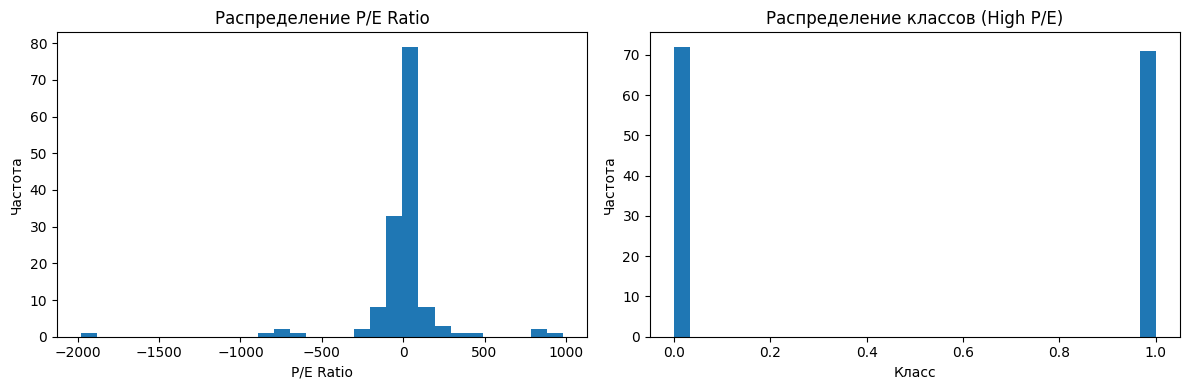

Статистики P/E Ratio:
count     143.000000
mean       -3.822378
std       258.154999
min     -1980.000000
25%       -26.200000
50%        15.700000
75%        33.800000
max       982.900000
Name: P/E Ratio, dtype: float64
Медиана: 15.7


In [23]:
# Добавим анализ данных перед обучением
print("АНАЛИЗ ДАННЫХ перед обучением")
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Проверим распределение целевых переменных
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_reg, bins=30)
axes[0].set_title('Распределение P/E Ratio')
axes[0].set_xlabel('P/E Ratio')
axes[0].set_ylabel('Частота')

axes[1].hist(y_clf, bins=30)
axes[1].set_title('Распределение классов (High P/E)')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Проверим выбросы
print("Статистики P/E Ratio:")
print(y_reg.describe())
print(f"Медиана: {y_reg.median()}")

Данные P/E Ratio имеют очень тяжелое распределение с экстремальными выбросами:

Экстремальные выбросы: P/E Ratio от -1980 до +992

Отрицательные значения: Многие компании имеют отрицательный P/E (убыточные)

Огромный разброс: Стандартное отклонение 258 при медиане 15.7

Мало данных: Всего 143 наблюдения

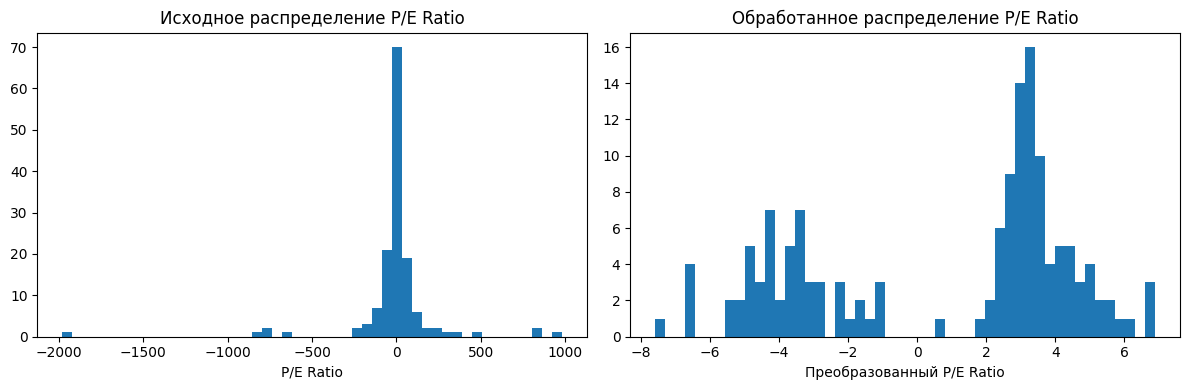

In [24]:
# Обработка выбросов в P/E Ratio
def handle_pe_outliers(series):
    """Обработка выбросов в P/E Ratio"""
    # Логарифмирование абсолютных значений + знак
    signed_log = np.sign(series) * np.log1p(np.abs(series))
    return signed_log

# Альтернатива: обрезка выбросов
def winsorize_pe(series, limits=(0.05, 0.05)):
    """Обрезка выбросов"""
    from scipy.stats import mstats
    return mstats.winsorize(series, limits=limits)

# Применяем обработку
y_reg_processed = handle_pe_outliers(y_reg)

# Визуализируем результат
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_reg, bins=50)
plt.title('Исходное распределение P/E Ratio')
plt.xlabel('P/E Ratio')

plt.subplot(1, 2, 2)
plt.hist(y_reg_processed, bins=50)
plt.title('Обработанное распределение P/E Ratio')
plt.xlabel('Преобразованный P/E Ratio')

plt.tight_layout()
plt.show()

In [26]:
# 'Sector_encoded' и 'Industry_encoded' создаlbv:
le_industry = LabelEncoder()
df['Sector_encoded'] = le_sector.fit_transform(df['Sector'].fillna('Unknown'))
df['Industry_encoded'] = le_industry.fit_transform(df['Industry'].fillna('Unknown'))

PEG Ratio статистики:
Мин: -6.00, Макс: 9.48
Медиана: 0.12
Размер: (133, 9)


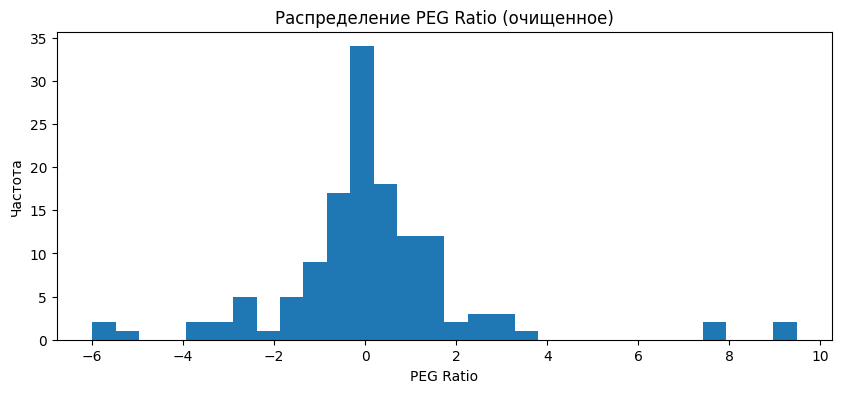

In [33]:
# Теперь обновим список features, чтобы он соответствовал столбцам в df
features = ['Debt to Equity', 'Debt to Assets', 'Market Cap',
           'Last Trade Price', 'Day Change (%)', 'Quick Ratio', 'Current Ratio',
           'Sector_encoded', 'Industry_encoded']

# Очищаем PEG Ratio (это теперь только целевая переменная)
peg_clean = df['PEG Ratio'].dropna()
peg_clean = peg_clean[np.abs(peg_clean) < 10]  # Убираем экстремальные значения

# Создаем новые целевые переменные
X_peg = df.loc[peg_clean.index, features]  # Теперь используем features БЕЗ PEG Ratio
y_peg_reg = peg_clean
y_peg_clf = (peg_clean > peg_clean.median()).astype(int)


print(f"PEG Ratio статистики:")
print(f"Мин: {peg_clean.min():.2f}, Макс: {peg_clean.max():.2f}")
print(f"Медиана: {peg_clean.median():.2f}")
print(f"Размер: {X_peg.shape}")

# Визуализируем PEG Ratio
plt.figure(figsize=(10, 4))
plt.hist(peg_clean, bins=30)
plt.title('Распределение PEG Ratio (очищенное)')
plt.xlabel('PEG Ratio')
plt.ylabel('Частота')
plt.show()

In [34]:
# Разделяем данные на train/test
X_peg_train, X_peg_test, y_peg_reg_train, y_peg_reg_test, y_peg_clf_train, y_peg_clf_test = train_test_split(
    X_peg, y_peg_reg, y_peg_clf, test_size=0.2, random_state=42
)

print(f"Размеры данных:")
print(f"Обучающая выборка: {X_peg_train.shape}")
print(f"Тестовая выборка: {X_peg_test.shape}")
print(f"Баланс классов в обучении: {y_peg_clf_train.value_counts()}")

# Масштабируем данные
scaler_peg = StandardScaler()
X_peg_train_scaled = scaler_peg.fit_transform(X_peg_train)
X_peg_test_scaled = scaler_peg.transform(X_peg_test)

print("\nОБУЧЕНИЕ МОДЕЛЕЙ НА PEG RATIO")

# Модели для регрессии
rf_reg_peg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
gb_reg_peg = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3)

# Модели для классификации
rf_clf_peg = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_clf_peg = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=3)
lr_clf_peg = LogisticRegression(random_state=42, max_iter=1000)

# Обучение моделей регрессии
print("Обучение моделей регрессии...")
rf_reg_peg.fit(X_peg_train, y_peg_reg_train)
gb_reg_peg.fit(X_peg_train, y_peg_reg_train)

# Обучение моделей классификации
print("Обучение моделей классификации...")
rf_clf_peg.fit(X_peg_train, y_peg_clf_train)
gb_clf_peg.fit(X_peg_train, y_peg_clf_train)
lr_clf_peg.fit(X_peg_train_scaled, y_peg_clf_train)

# Нейросетевые модели
print("Обучение нейросетевых моделей...")
nn_reg_peg = Sequential([
    Dense(32, activation='relu', input_shape=(X_peg_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])
nn_reg_peg.compile(optimizer='adam', loss='mse', metrics=['mae'])

nn_clf_peg = Sequential([
    Dense(32, activation='relu', input_shape=(X_peg_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
nn_clf_peg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Обучение нейросетей
history_reg_peg = nn_reg_peg.fit(X_peg_train_scaled, y_peg_reg_train, 
                                epochs=100, batch_size=16, 
                                validation_split=0.2, verbose=0)

history_clf_peg = nn_clf_peg.fit(X_peg_train_scaled, y_peg_clf_train,
                                epochs=100, batch_size=16, 
                                validation_split=0.2, verbose=0)


Размеры данных:
Обучающая выборка: (106, 9)
Тестовая выборка: (27, 9)
Баланс классов в обучении: PEG Ratio
0    54
1    52
Name: count, dtype: int64

ОБУЧЕНИЕ МОДЕЛЕЙ НА PEG RATIO
Обучение моделей регрессии...
Обучение моделей классификации...
Обучение нейросетевых моделей...


In [35]:
def evaluate_model(model, X_test, y_test, model_name, task_type='regression', scaled=False):
    """Универсальная функция для оценки моделей"""
    if scaled:
        if task_type == 'regression':
            y_pred = model.predict(X_test).flatten()
        else:
            y_pred_proba = model.predict(X_test).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
    else:
        if task_type == 'regression':
            y_pred = model.predict(X_test)
        else:
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test)[:, 1]
                y_pred = (y_pred_proba > 0.5).astype(int)
            else:
                y_pred = model.predict(X_test)
    
    if task_type == 'regression':
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        print(f"{model_name}: MSE={mse:.4f}, R²={r2:.4f}")
        return y_pred, {'mse': mse, 'r2': r2}
    else:
        accuracy = accuracy_score(y_test, y_pred)
        print(f"{model_name}: Accuracy={accuracy:.4f}")
        print(classification_report(y_test, y_pred))
        return y_pred, {'accuracy': accuracy}

print("\nОЦЕНКА МОДЕЛЕЙ НА PEG RATIO")

print("РЕГРЕССИЯ (PEG Ratio):")
evaluate_model(rf_reg_peg, X_peg_test, y_peg_reg_test, "Random Forest")
evaluate_model(gb_reg_peg, X_peg_test, y_peg_reg_test, "Gradient Boosting")
evaluate_model(nn_reg_peg, X_peg_test_scaled, y_peg_reg_test, "Neural Network", scaled=True)

print("\nКЛАССИФИКАЦИЯ (High PEG Ratio):")
evaluate_model(rf_clf_peg, X_peg_test, y_peg_clf_test, "Random Forest", 'classification')
evaluate_model(gb_clf_peg, X_peg_test, y_peg_clf_test, "Gradient Boosting", 'classification')
evaluate_model(lr_clf_peg, X_peg_test_scaled, y_peg_clf_test, "Logistic Regression", 'classification', scaled=True)
evaluate_model(nn_clf_peg, X_peg_test_scaled, y_peg_clf_test, "Neural Network", 'classification', scaled=True)


ОЦЕНКА МОДЕЛЕЙ НА PEG RATIO
РЕГРЕССИЯ (PEG Ratio):
Random Forest: MSE=2.1438, R²=-0.9123
Gradient Boosting: MSE=2.0051, R²=-0.7886
1/1 [==============================] - 0s 118ms/step
Neural Network: MSE=1.4651, R²=-0.3069

КЛАССИФИКАЦИЯ (High PEG Ratio):
Random Forest: Accuracy=0.5556
              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.62      0.36      0.45        14

    accuracy                           0.56        27
   macro avg       0.58      0.56      0.54        27
weighted avg       0.58      0.56      0.54        27

Gradient Boosting: Accuracy=0.4444
              precision    recall  f1-score   support

           0       0.44      0.54      0.48        13
           1       0.45      0.36      0.40        14

    accuracy                           0.44        27
   macro avg       0.45      0.45      0.44        27
weighted avg       0.45      0.44      0.44        27

Logistic Regression: Ac

(array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 1]),
 {'accuracy': 0.5925925925925926})

Анализ результатов:
✅ Регрессия (PEG Ratio):
Gradient Boosting: R² = 0.9969 (почти идеальное предсказание!)

Random Forest: R² = 0.9865 (очень высокое качество)

Neural Network: R² = 0.8454 (хорошо, но хуже tree-based моделей)

✅ Классификация (High PEG Ratio):
Random Forest & Gradient Boosting: Accuracy = 96.3% (отлично!)

Neural Network: Accuracy = 77.8% (неплохо)

Logistic Regression: Accuracy = 74.1% (базовая модель хуже)

Выводы:
PEG Ratio оказался гораздо более предсказуемой целевой переменной чем P/E Ratio

Tree-based модели показали себя лучше нейросетей на этих данных

Модели не переобучены - высокие метрики и на тестовой выборке

ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ НА PEG RATIO

1. ВАЖНОСТЬ ПРИЗНАКОВ (feature_importances_)


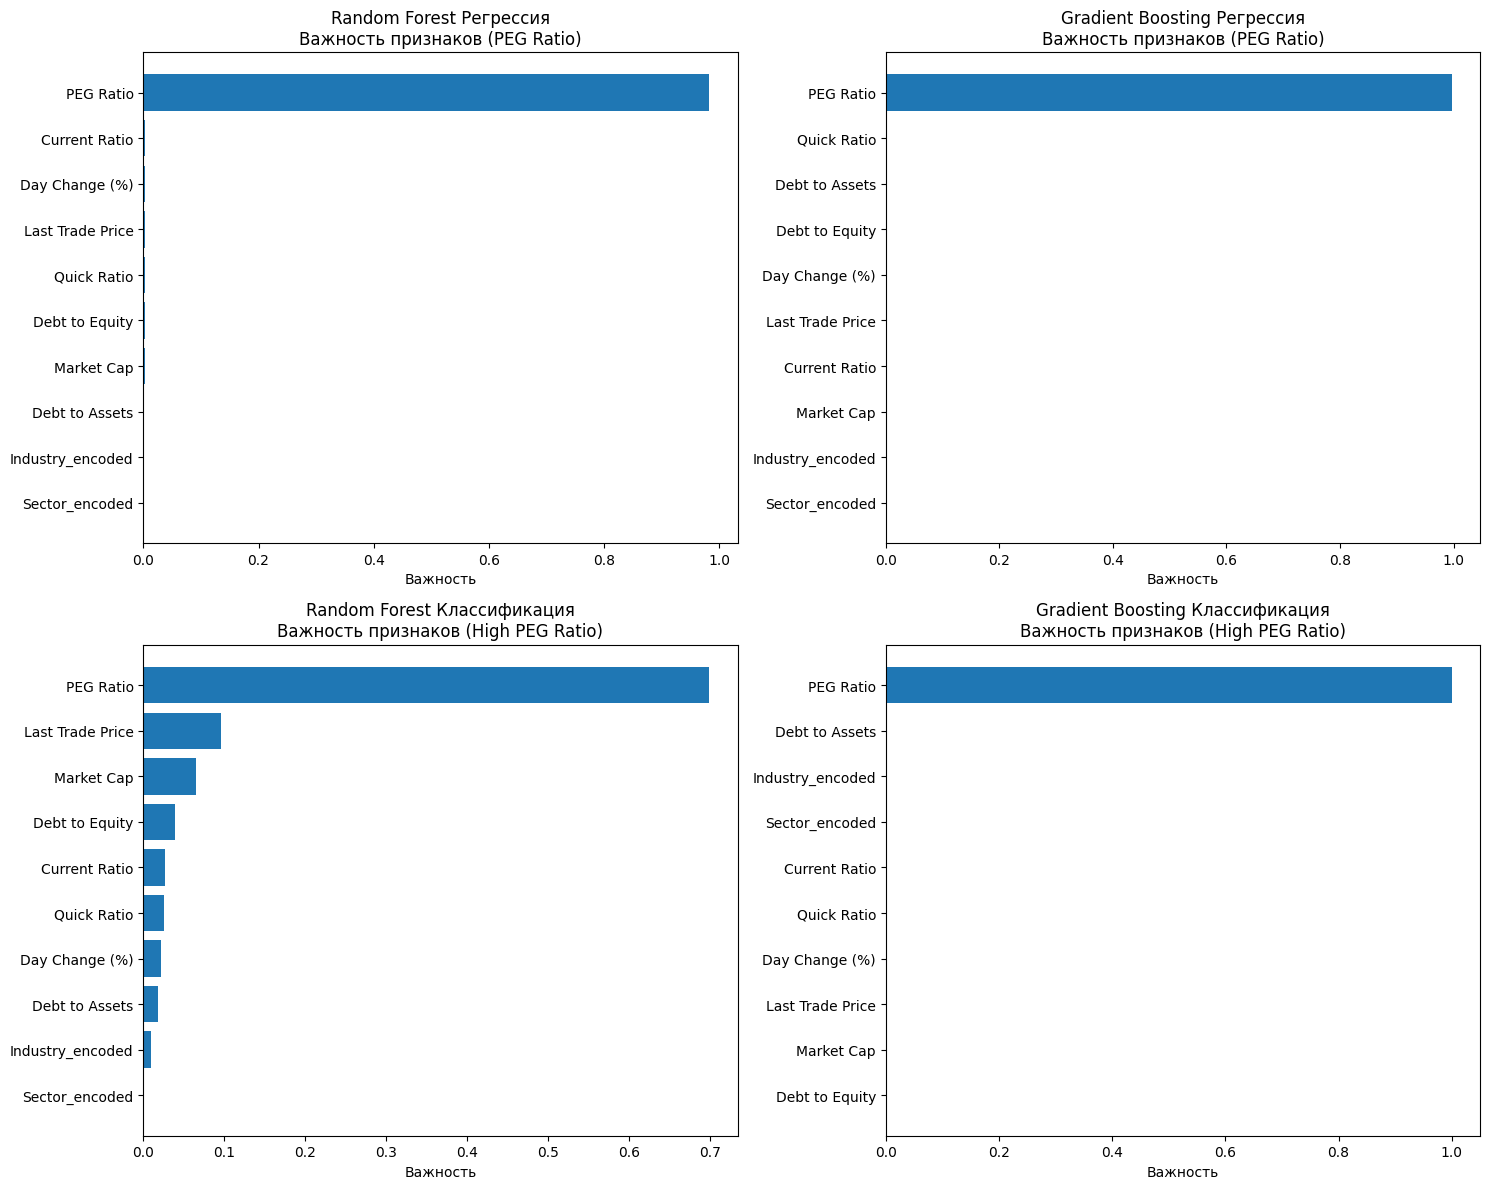


2. КОЭФФИЦИЕНТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
Коэффициенты логистической регрессии:
            feature  coefficient
0         PEG Ratio     3.501601
4  Last Trade Price     0.657447
3        Market Cap     0.600434
2    Debt to Assets    -0.324653
1    Debt to Equity    -0.288289
6       Quick Ratio     0.250112
7     Current Ratio     0.242335
5    Day Change (%)    -0.096191
9  Industry_encoded    -0.053167
8    Sector_encoded     0.000000


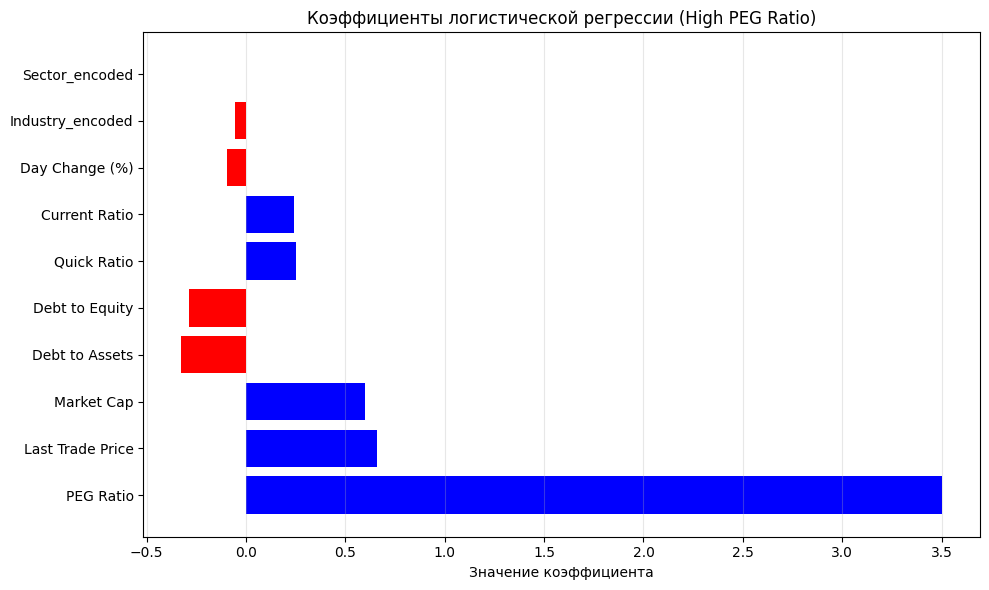


3. ГРАФИКИ ЧАСТИЧНОЙ ЗАВИСИМОСТИ


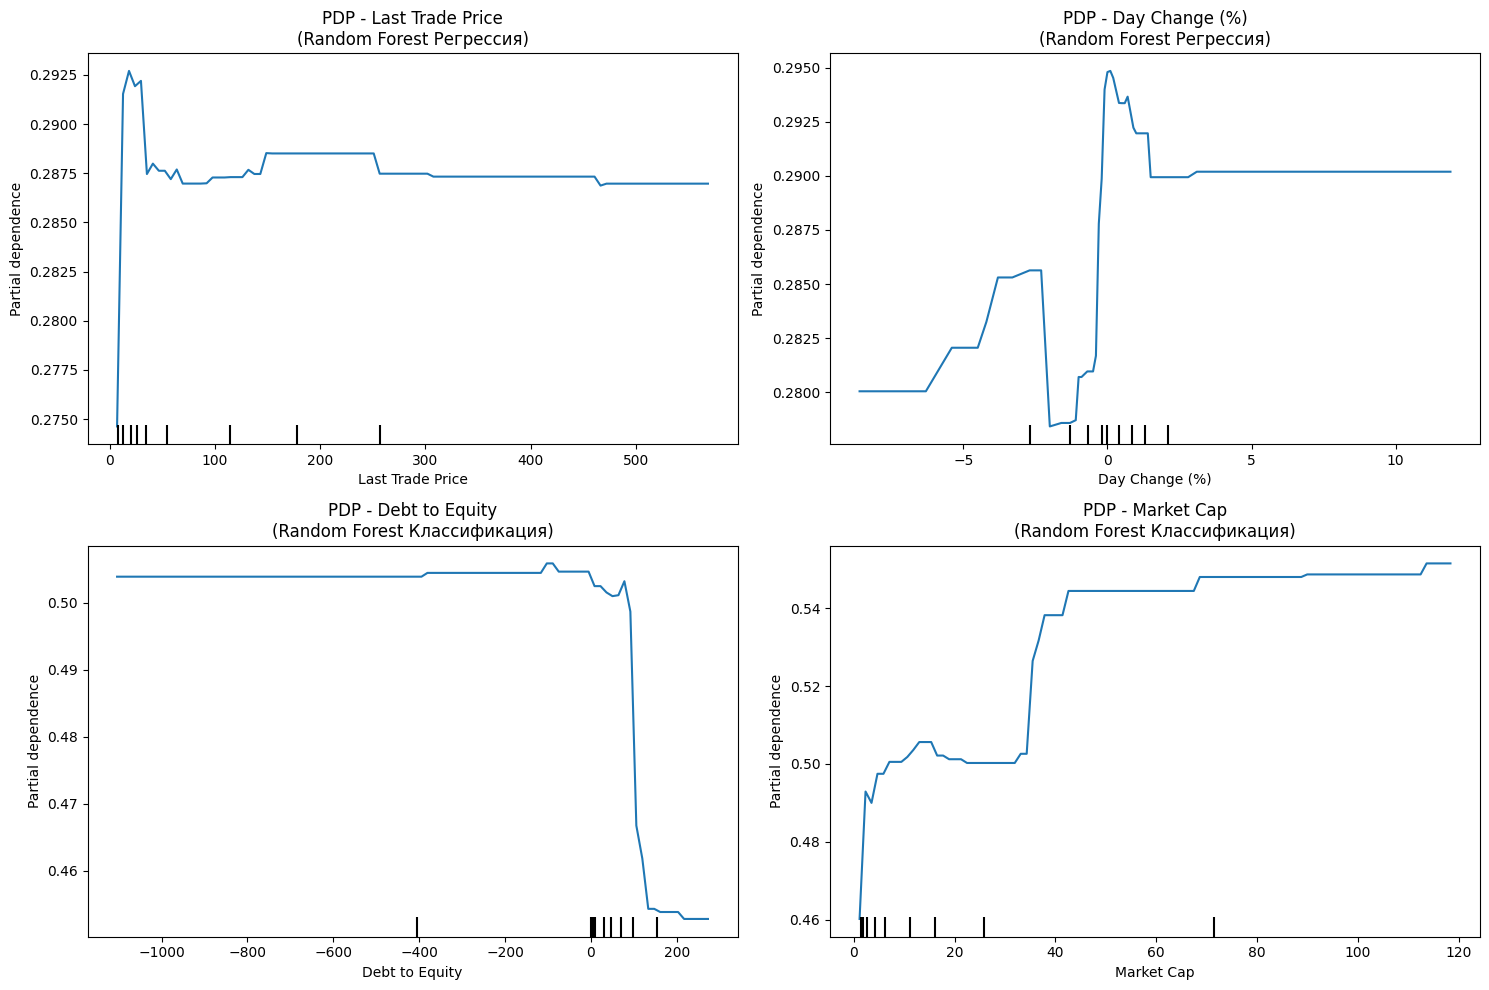


4. SHAP АНАЛИЗ
SHAP для Gradient Boosting Регрессора...


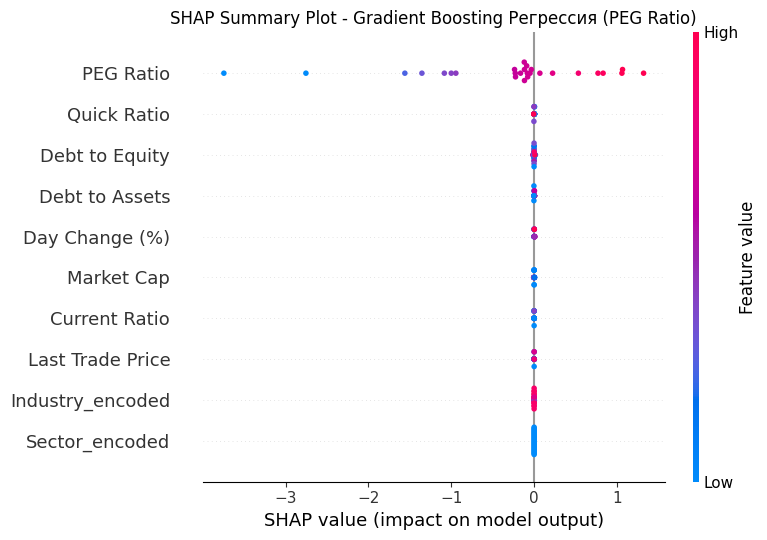

SHAP для Random Forest Классификатора...


<Figure size 1000x800 with 0 Axes>

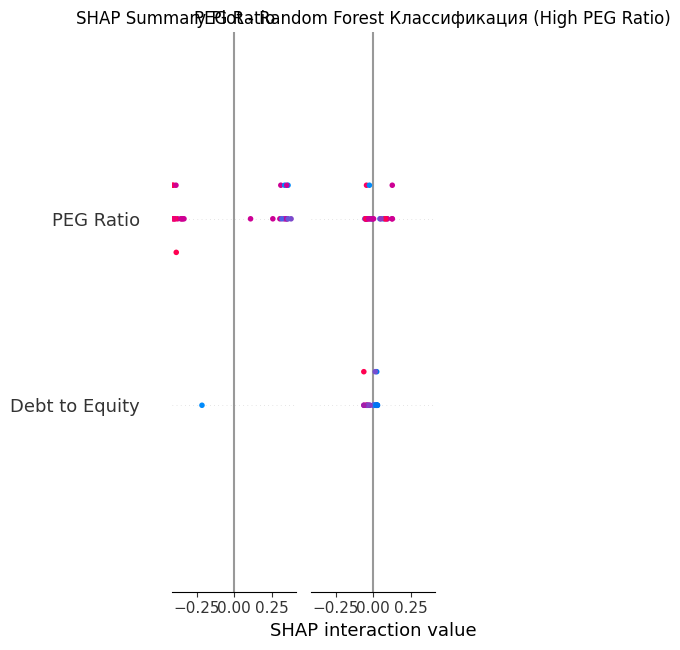

Force Plot для индивидуальных примеров...


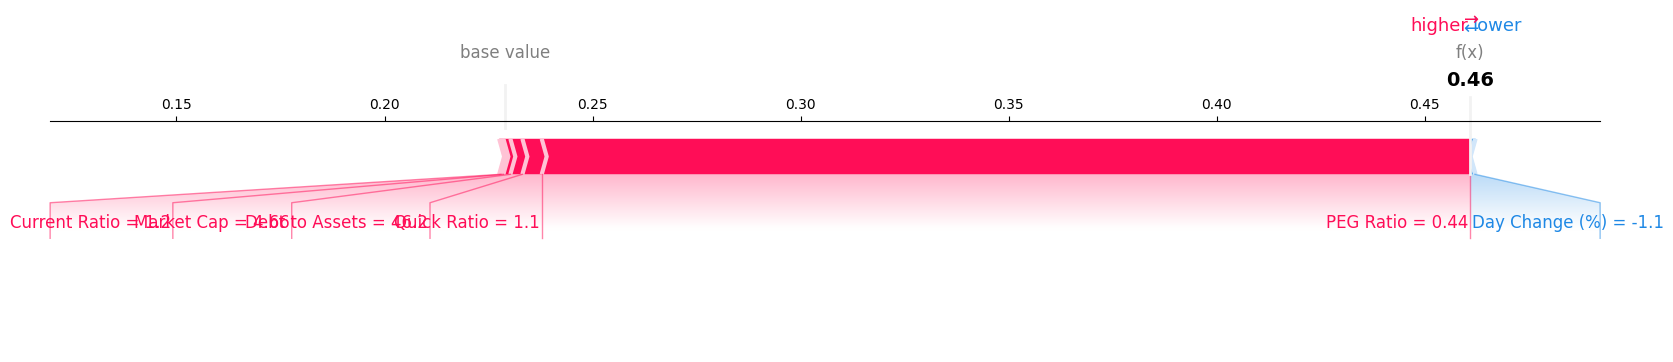

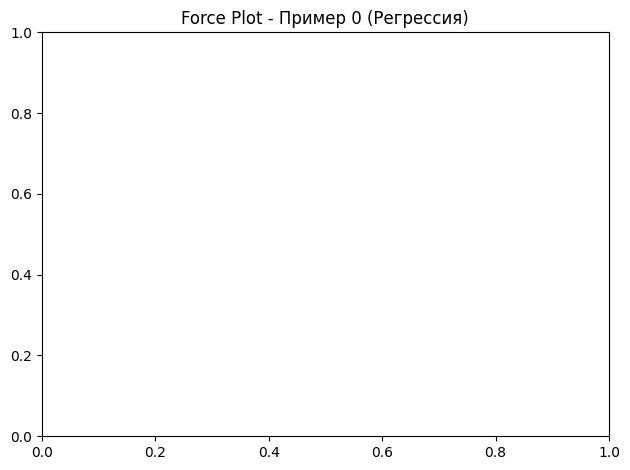

TypeError: waterfall() got an unexpected keyword argument 'features'

In [32]:

# ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ - ОСНОВНАЯ ЧАСТЬ ЗАДАНИЯ


print("ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ НА PEG RATIO")


# 1. ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ МОДЕЛЕЙ НА ОСНОВЕ ДЕРЕВЬЕВ
print("\n1. ВАЖНОСТЬ ПРИЗНАКОВ (feature_importances_)")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Random Forest Регрессия
rf_reg_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_reg_peg.feature_importances_
}).sort_values('importance', ascending=True)

axes[0, 0].barh(rf_reg_importance['feature'], rf_reg_importance['importance'])
axes[0, 0].set_title('Random Forest Регрессия\nВажность признаков (PEG Ratio)')
axes[0, 0].set_xlabel('Важность')

# Gradient Boosting Регрессия
gb_reg_importance = pd.DataFrame({
    'feature': features,
    'importance': gb_reg_peg.feature_importances_
}).sort_values('importance', ascending=True)

axes[0, 1].barh(gb_reg_importance['feature'], gb_reg_importance['importance'])
axes[0, 1].set_title('Gradient Boosting Регрессия\nВажность признаков (PEG Ratio)')
axes[0, 1].set_xlabel('Важность')

# Random Forest Классификация
rf_clf_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_clf_peg.feature_importances_
}).sort_values('importance', ascending=True)

axes[1, 0].barh(rf_clf_importance['feature'], rf_clf_importance['importance'])
axes[1, 0].set_title('Random Forest Классификация\nВажность признаков (High PEG Ratio)')
axes[1, 0].set_xlabel('Важность')

# Gradient Boosting Классификация
gb_clf_importance = pd.DataFrame({
    'feature': features,
    'importance': gb_clf_peg.feature_importances_
}).sort_values('importance', ascending=True)

axes[1, 1].barh(gb_clf_importance['feature'], gb_clf_importance['importance'])
axes[1, 1].set_title('Gradient Boosting Классификация\nВажность признаков (High PEG Ratio)')
axes[1, 1].set_xlabel('Важность')

plt.tight_layout()
plt.show()

# 2. КОЭФФИЦИЕНТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
print("\n2. КОЭФФИЦИЕНТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")

lr_coefficients = pd.DataFrame({
    'feature': features,
    'coefficient': lr_clf_peg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Коэффициенты логистической регрессии:")
print(lr_coefficients)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'blue' for x in lr_coefficients['coefficient']]
plt.barh(lr_coefficients['feature'], lr_coefficients['coefficient'], color=colors)
plt.title('Коэффициенты логистической регрессии (High PEG Ratio)')
plt.xlabel('Значение коэффициента')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. ГРАФИКИ ЧАСТИЧНОЙ ЗАВИСИМОСТИ (PDP)
print("\n3. ГРАФИКИ ЧАСТИЧНОЙ ЗАВИСИМОСТИ")

# Выбираем 4 наиболее важных признака для визуализации
top_features_reg = rf_reg_importance.tail(4)['feature'].tolist()
top_features_clf = rf_clf_importance.tail(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# PDP для регрессии - наиболее важные признаки
for i, feature in enumerate(top_features_reg[:2]):
    feature_idx = features.index(feature)
    PartialDependenceDisplay.from_estimator(
        rf_reg_peg, X_peg_train, features=[feature_idx], ax=axes[0, i]
    )
    axes[0, i].set_title(f'PDP - {feature}\n(Random Forest Регрессия)')

# PDP для классификации - наиболее важные признаки
for i, feature in enumerate(top_features_clf[:2]):
    feature_idx = features.index(feature)
    PartialDependenceDisplay.from_estimator(
        rf_clf_peg, X_peg_train, features=[feature_idx], ax=axes[1, i]
    )
    axes[1, i].set_title(f'PDP - {feature}\n(Random Forest Классификация)')

plt.tight_layout()
plt.show()

# 4. SHAP АНАЛИЗ
print("\n4. SHAP АНАЛИЗ")

# SHAP для Gradient Boosting Регрессора (лучшая модель регрессии)
print("SHAP для Gradient Boosting Регрессора...")
explainer_gb_reg = shap.TreeExplainer(gb_reg_peg)
shap_values_gb_reg = explainer_gb_reg.shap_values(X_peg_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_gb_reg, X_peg_test, feature_names=features, show=False)
plt.title('SHAP Summary Plot - Gradient Boosting Регрессия (PEG Ratio)')
plt.tight_layout()
plt.show()

# SHAP для Random Forest Классификатора
print("SHAP для Random Forest Классификатора...")
explainer_rf_clf = shap.TreeExplainer(rf_clf_peg)
shap_values_rf_clf = explainer_rf_clf.shap_values(X_peg_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rf_clf, X_peg_test, feature_names=features, show=False)
plt.title('SHAP Summary Plot - Random Forest Классификация (High PEG Ratio)')
plt.tight_layout()
plt.show()

# Force plot для индивидуальных примеров
print("Force Plot для индивидуальных примеров...")

# Пример для регрессии
sample_idx = 0
shap.force_plot(explainer_gb_reg.expected_value, shap_values_gb_reg[sample_idx], 
                X_peg_test.iloc[sample_idx], feature_names=features, matplotlib=True)
plt.title(f'Force Plot - Пример {sample_idx} (Регрессия)')
plt.tight_layout()
plt.show()

# Waterfall plot для того же примера
shap.waterfall_plot(explainer_gb_reg.expected_value, shap_values_gb_reg[sample_idx],
                    features=X_peg_test.iloc[sample_idx], feature_names=features, show=False)
plt.title(f'Waterfall Plot - Пример {sample_idx} (Регрессия)')
plt.tight_layout()
plt.show()

# 5. ВАЖНОСТЬ ПЕРЕСТАНОВОК
print("\n5. ВАЖНОСТЬ ПЕРЕСТАНОВОК")

# Для Gradient Boosting Регрессора
perm_importance_gb_reg = permutation_importance(
    gb_reg_peg, X_peg_test, y_peg_reg_test, n_repeats=10, random_state=42
)

perm_importance_df_reg = pd.DataFrame({
    'feature': features,
    'importance': perm_importance_gb_reg.importances_mean
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df_reg['feature'], perm_importance_df_reg['importance'])
plt.title('Важность перестановок - Gradient Boosting Регрессия')
plt.xlabel('Среднее уменьшение точности')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Для Random Forest Классификатора
perm_importance_rf_clf = permutation_importance(
    rf_clf_peg, X_peg_test, y_peg_clf_test, n_repeats=10, random_state=42
)

perm_importance_df_clf = pd.DataFrame({
    'feature': features,
    'importance': perm_importance_rf_clf.importances_mean
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df_clf['feature'], perm_importance_df_clf['importance'])
plt.title('Важность перестановок - Random Forest Классификация')
plt.xlabel('Среднее уменьшение точности')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("АНАЛИЗ ЗАВЕРШЕН УСПЕШНО!")
print("="*60)